# F1 2026 Japanese GP Qualifying Lap Time Prediction and Race Strategy

## Introduction

This notebook analyzes FP1-FP3 data from the 2026 Japanese Grand Prix to understand how practice-session behavior translates into qualifying-style lap pace. The workflow combines data preparation, exploratory analysis, and regression modeling to estimate lap time under controlled assumptions.

The goal is not just to rank teams by raw pace. It is to identify which combinations of session context, tyre state, driver identity, and speed indicators explain the lap-time variation seen before qualifying.

### Event Context

Suzuka Circuit rewards high-speed aerodynamic stability through “S” curves with committed cornering speed, and driver confidence in changes of direction. That makes lap time sensitive to front tyre wear over a full stint, fuel-load sensitivity through the high-speed sections, track evolution across the weekend, and the specific balance between qualifying one-lap pace and long-run degradation in high-grip conditions.

Using FP1-FP3 data from all teams keeps the analysis representative of the full grid while preserving enough variation for meaningful comparison and model training.

![Suzuka Circuit map](2026tracksuzukadetailed.png)

| Circuit Length (KM) | Number of Laps | Race Distance (KM) | First Grand Prix | Fastest Lap Time | Driver | Team | Year |
| :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| 5.807 | 53 | 307.471 | 1987 | 1:30.965 (90.965 sec) | Kimi Antonelli | Mercedes | 2025 |

### Research Objectives

1. Quantify the main factors associated with lap-time variation across all selected teams.
2. Examine how pace changes across sessions, stints, tyre compounds, and tyre life.
3. Benchmark ensemble regression models for qualifying-oriented lap-time prediction.
4. Translate the best model into a driver-level tyre-life sensitivity view for qualifying scenarios.

## Data Preparation

This section loads the Japanese GP practice data, checks whether local exports already exist, and rebuilds the dataset from FastF1 only when needed. The intent is to keep the notebook reproducible and fast to rerun while preserving a clear path from source data to modeling inputs.

In [1]:
# Importing libraries for data analysis
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import fastf1 as ff1
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.utils import resample
from itertools import product

# Define event/session metadata once and reuse across notebook
year = 2026
gp = 'Japanese Grand Prix'
cache_gp = 'japanese_gp'
cache_data = f"./f1_{year}_{cache_gp}_cache"
session_names = ['FP1', 'FP2', 'FP3']
qualifying_session_names = ['Q']

# Define CSV file paths
csv_file = f'f1_{year}_{cache_gp}_combined_laps.csv'
cleaned_csv_file = f'f1_{year}_{cache_gp}_cleaned_laps.csv'
qualifying_csv_file = f'f1_{year}_{cache_gp}_qualifying_laps.csv'
qualifying_cleaned_csv_file = f'f1_{year}_{cache_gp}_qualifying_cleaned_laps.csv'

# Race and pit constants
RACE_LAPS = 53
PIT_STOP_LOSS = 22.0
WARM_UP_LAPS = 3
COMPOUNDS = ['SOFT', 'MEDIUM', 'HARD']

# Keep a stable schema when qualifying is unavailable
qualifying_fallback_columns = ['Session', 'Team', 'Driver', 'DriverNumber', 'LapNumber', 'Stint',
                               'LapTime', 'Compound', 'TyreLife', 'SpeedST', 'TrackStatus'
                               ]

# Prepare cache and event
os.makedirs(cache_data, exist_ok=True)
ff1.Cache.enable_cache(cache_data)
event = ff1.get_event(year, gp)

# Shared session cache for downstream telemetry/map analysis
sessions_by_name = {}
session_laps_by_name = {}
qualifying_laps_by_name = {}

def load_sessions_once(load_telemetry=True):
    for session_name in session_names:
        if session_name in sessions_by_name:
            continue
        try:
            print(f"Loading {session_name}")
            session = event.get_session(session_name)
            session.load(telemetry=load_telemetry, weather=True, messages=False)
            sessions_by_name[session_name] = session

            session_laps = session.laps.copy()
            session_laps['Session'] = session_name
            session_laps_by_name[session_name] = session_laps
            print(f"Loaded {len(session.laps)} laps from {session_name}")
        except Exception as exc:
            print(f"Warning: {session_name} unavailable or failed to load ({exc}). Skipping this session.")

def load_qualifying_sessions_once(load_telemetry=True):
    for qualifying_session_name in qualifying_session_names:
        if qualifying_session_name in qualifying_laps_by_name:
            continue
        try:
            print(f"Loading {qualifying_session_name}")
            qualifying_session = event.get_session(qualifying_session_name)
            qualifying_session.load(telemetry=load_telemetry, weather=True, messages=False)
            sessions_by_name[qualifying_session_name] = qualifying_session

            qualifying_laps = qualifying_session.laps.copy()
            qualifying_laps['Session'] = qualifying_session_name
            qualifying_laps_by_name[qualifying_session_name] = qualifying_laps
            print(f"Loaded {len(qualifying_laps)} laps from {qualifying_session_name}")
        except Exception as exc:
            print(f"Warning: {qualifying_session_name} unavailable or failed to load ({exc}). Skipping this session.")

# Always initialize these so downstream cells are deterministic
practice_data = None
qualifying_data = None

# Check if CSV file already exists
if os.path.exists(csv_file):
    print(f"Loading data from existing CSV file: {csv_file}")
    practice_data = pd.read_csv(csv_file)
    data = practice_data.copy()
    print(f"Total laps in practice dataset: {len(practice_data)}")

    if os.path.exists(qualifying_csv_file):
        print(f"Loading qualifying data from existing CSV file: {qualifying_csv_file}")
        qualifying_data = pd.read_csv(qualifying_csv_file)
    else:
        print("Qualifying CSV not found. Pulling qualifying sessions from FastF1 cache/API.")
        load_qualifying_sessions_once(load_telemetry=True)
        all_qualifying_laps = [qualifying_laps_by_name[s] for s in qualifying_session_names if s in qualifying_laps_by_name]
        if len(all_qualifying_laps) > 0:
            qualifying_data = pd.concat(all_qualifying_laps, ignore_index=True)
            qualifying_data.to_csv(qualifying_csv_file, index=False)
        else:
            print("Warning: No qualifying sessions available; using empty fallback qualifying dataset.")
            qualifying_data = pd.DataFrame(columns=qualifying_fallback_columns)

    # Load sessions once here so telemetry/race-map cells can reuse them
    print("Preparing session cache for telemetry and race map")
    load_sessions_once(load_telemetry=True)
    load_qualifying_sessions_once(load_telemetry=True)
else:
    print("CSV file not found. Pulling data from FastF1")

    # Load multiple sessions once and combine them
    load_sessions_once(load_telemetry=True)
    all_laps = [session_laps_by_name[s] for s in session_names if s in session_laps_by_name]
    load_qualifying_sessions_once(load_telemetry=True)
    all_qualifying_laps = [qualifying_laps_by_name[s] for s in qualifying_session_names if s in qualifying_laps_by_name]

    if len(all_laps) == 0:
        raise RuntimeError(
            f"No practice sessions in {session_names} could be loaded. "
            "Please check FastF1 cache/network availability or provide the combined CSV file."
        )
    practice_data = pd.concat(all_laps, ignore_index=True)
    data = practice_data.copy()

    if len(all_qualifying_laps) == 0:
        raise RuntimeError(
            f"No qualifying sessions in {qualifying_session_names} could be loaded. "
            "Please check FastF1 cache/network availability or provide the qualifying CSV file."
        )
    qualifying_data = pd.concat(all_qualifying_laps, ignore_index=True)

    # Save the combined dataframe to a CSV file
    practice_data.to_csv(csv_file, index=False)
    qualifying_data.to_csv(qualifying_csv_file, index=False)

print(f"\nPractice Data saved to {csv_file}")
print(f"Total laps in practice dataset: {len(practice_data)}")

print(f"\nQualifying Data saved to {qualifying_csv_file}")
print(f"Total laps in qualifying dataset: {len(qualifying_data)}")

core           INFO 	Loading data for Japanese Grand Prix - Practice 1 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


Loading data from existing CSV file: f1_2026_japanese_gp_combined_laps.csv
Total laps in practice dataset: 1512
Loading qualifying data from existing CSV file: f1_2026_japanese_gp_qualifying_laps.csv
Preparing session cache for telemetry and race map
Loading FP1


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	No cached data found for weather_data. Loading data...
_api           INFO 	Fetching weather data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '16', '18', '23', '27', '30', '31', '34', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Japanese Grand Prix - Practice 2 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for

Loaded 529 laps from FP1
Loading FP2


req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	No cached data found for weather_data. Loading data...
_api           INFO 	Fetching weather data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Japanese Grand Prix - Practice 3 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...


Loaded 547 laps from FP2
Loading FP3


core        WARNING 	Driver 30: Lap timing integrity check failed for 1 lap(s)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	No cached data found for weather_data. Loading data...
_api           INFO 	Fetching weather data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 22 drivers: ['1', '3', '5', '6', '10', '11', '12', '14', '16', '18', '23', '27', '30', '31', '41', '43', '44', '55', '63', '77', '81', '87']
core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core      

Loaded 436 laps from FP3
Loading Q


req            INFO 	No cached data found for car_data. Loading data...
_api           INFO 	Fetching car data...
_api           INFO 	Parsing car data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for position_data. Loading data...
_api           INFO 	Fetching position data...
_api           INFO 	Parsing position data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for weather_data. Loading data...
_api           INFO 	Fetching weather data...
req            INFO 	Data has been written to cache!
core           INFO 	Finished loading data for 22 drivers: ['12', '63', '81', '16', '1', '44', '10', '6', '5', '41', '3', '31', '27', '30', '43', '55', '23', '87', '11', '77', '14', '18']


Loaded 324 laps from Q

Practice Data saved to f1_2026_japanese_gp_combined_laps.csv
Total laps in practice dataset: 1512

Qualifying Data saved to f1_2026_japanese_gp_qualifying_laps.csv
Total laps in qualifying dataset: 324


### Data Preprocessing

This preprocessing step standardizes lap-level records before analysis.

1. Convert timing fields to numeric seconds.
2. Remove deleted or inaccurate laps that would distort pace comparisons.
3. Drop columns that are not required for this notebook's analysis path.
4. Export the cleaned dataset so the processed source can be reused consistently.

In [2]:
# Cleaning the data
def data_cleaning(data, output_csv_path):
    cleaned_data = data.copy()

    # Convert all time columns to seconds
    time_columns = ['LapTime', 'Sector1Time', 'Sector2Time', 'Sector3Time']
    for col in time_columns:
        if col in cleaned_data.columns:
            # If already numeric (seconds), keep as-is
            if pd.api.types.is_numeric_dtype(cleaned_data[col]):
                cleaned_data[col] = pd.to_numeric(cleaned_data[col], errors='coerce')
            else:
                # Handle strings/timedelta-like values
                cleaned_data[col] = pd.to_timedelta(cleaned_data[col], errors='coerce').dt.total_seconds()

    # Remove deleted laps (commonly deleted for track limits)
    if 'Deleted' in cleaned_data.columns:
        deleted_mask = cleaned_data['Deleted'].astype(str).str.lower().isin(['true', '1', 'yes'])
        removed_count = int(deleted_mask.sum())
        cleaned_data = cleaned_data.loc[~deleted_mask].copy()
        print(f"Removed {removed_count} deleted laps.")

    # Remove inaccurate laps (e.g., those with missing or zero lap times)
    if 'IsAccurate' in cleaned_data.columns:
        accurate_mask = cleaned_data['IsAccurate'].astype(str).str.lower().isin(['false', '0', 'no'])
        accurate_count = int(accurate_mask.sum())
        cleaned_data = cleaned_data.loc[~accurate_mask].copy()
        print(f"Removed {accurate_count} inaccurate laps.")

    # Drop unnecessary columns (if any)
    columns_to_drop = ['Time', 'PitOutTime', 'PitInTime', 'PitDuration', 'LapStartTime', 'LapEndTime',
                       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'LapStartDateTime',
                       'LapStartDate', 'LapEndDateTime','Position', 'Deleted', 'DeletedReason', 'FastF1Generated','IsAccurate']
    cleaned_data = cleaned_data.drop(columns=[col for col in columns_to_drop if col in cleaned_data.columns])

    # Drop reserve drivers or any other non-regular participants if identifiable (e.g., by team or driver name patterns)
    if 'Driver' in cleaned_data.columns:
        reserve_mask = cleaned_data['Driver'].str.contains('CRA', case=False, na=False)
        reserve_count = int(reserve_mask.sum())
        cleaned_data = cleaned_data.loc[~reserve_mask].copy()
        print(f"Removed {reserve_count} laps from reserve/test drivers.")

    # Save the cleaned dataframe to a CSV file
    cleaned_data.to_csv(output_csv_path, index=False)
    print(f"Cleaned data saved to {output_csv_path}")
    return cleaned_data

In [3]:
df = data_cleaning(data, cleaned_csv_file)
qualifying_df = data_cleaning(qualifying_data, qualifying_cleaned_csv_file)

Removed 0 deleted laps.
Removed 576 inaccurate laps.
Removed 5 laps from reserve/test drivers.
Cleaned data saved to f1_2026_japanese_gp_cleaned_laps.csv
Removed 0 deleted laps.
Removed 197 inaccurate laps.
Removed 0 laps from reserve/test drivers.
Cleaned data saved to f1_2026_japanese_gp_qualifying_cleaned_laps.csv


### Data Inspection

The inspection cells check that the cleaned dataset is structurally sound before any EDA or modeling begins. They confirm the table size, available columns, lap-time distribution, and the team-driver coverage that the later sections rely on.

In [4]:
# Display all data
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")
print("\nColumn names:")
print(df.columns.tolist())

# Display the dataframe
df

Total rows: 931
Total columns: 19

Column names:
['Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'TrackStatus', 'Session']


,Driver,DriverNumber,LapTime,LapNumber,Stint,Sector1Time,Sector2Time,Sector3Time,SpeedI1,SpeedI2,SpeedFL,SpeedST,IsPersonalBest,Compound,TyreLife,FreshTyre,Team,TrackStatus,Session
2,NOR,1,94.595,3.0,2.0,33.696,42.133,18.766,267.0,312.0,254.0,273.0,True,MEDIUM,3.0,False,McLaren,1,FP1
3,NOR,1,124.621,4.0,2.0,43.813,56.858,23.950,173.0,270.0,269.0,174.0,True,MEDIUM,4.0,False,McLaren,1,FP1
4,NOR,1,93.151,5.0,2.0,33.658,41.167,18.326,264.0,312.0,253.0,273.0,True,MEDIUM,5.0,False,McLaren,1,FP1
5,NOR,1,142.135,6.0,2.0,47.169,60.130,34.836,204.0,234.0,270.0,155.0,False,MEDIUM,6.0,False,McLaren,1,FP1
6,NOR,1,104.450,7.0,2.0,33.783,50.633,20.034,270.0,272.0,277.0,259.0,False,MEDIUM,7.0,False,McLaren,1,FP1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,BEA,87,92.378,4.0,1.0,33.640,40.671,18.067,275.0,324.0,252.0,279.0,True,MEDIUM,4.0,True,Haas F1 Team,1,FP3
1499,BEA,87,91.953,6.0,1.0,33.384,40.605,17.964,277.0,326.0,256.0,280.0,True,MEDIUM,6.0,True,Haas F1 Team,1,FP3
1501,BEA,87,91.558,8.0,1.0,33.368,40.445,17.745,278.0,327.0,264.0,281.0,True,MEDIUM,8.0,True,Haas F1 Team,1,FP3
1507,BEA,87,91.974,14.0,4.0,33.156,40.845,17.973,279.0,325.0,254.0,281.0,False,MEDIUM,12.0,False,Haas F1 Team,1,FP3


In [5]:
# Display basic info
print(f"Dataset shape after cleaning: {df.shape}")
print(f"\nLapTime statistics:")
print(df['LapTime'].describe())

Dataset shape after cleaning: (931, 19)

LapTime statistics:
count    931.000000
mean     105.077439
std       16.556767
min       89.362000
25%       93.372500
50%       96.413000
75%      117.918500
max      149.492000
Name: LapTime, dtype: float64


In [6]:
# Display available teams and drivers
print("Available Teams:")
print(df['Team'].unique())
print("\nAvailable Drivers:")
print(df[['Driver', 'DriverNumber', 'Team']].drop_duplicates().sort_values('Team').reset_index(drop=True))

Available Teams:
['McLaren' 'Red Bull Racing' 'Audi' 'Alpine' 'Cadillac' 'Mercedes'
 'Ferrari' 'Aston Martin' 'Williams' 'Racing Bulls' 'Haas F1 Team']

Available Drivers:
   Driver  DriverNumber             Team
0     COL            43           Alpine
1     GAS            10           Alpine
2     ALO            14     Aston Martin
3     STR            18     Aston Martin
4     HUL            27             Audi
5     BOR             5             Audi
6     PER            11         Cadillac
7     BOT            77         Cadillac
8     LEC            16          Ferrari
9     HAM            44          Ferrari
10    BEA            87     Haas F1 Team
11    OCO            31     Haas F1 Team
12    PIA            81          McLaren
13    NOR             1          McLaren
14    RUS            63         Mercedes
15    ANT            12         Mercedes
16    LAW            30     Racing Bulls
17    LIN            41     Racing Bulls
18    VER             3  Red Bull Racing
19    HA

In [7]:
# Set palettes
tyre_palette = {'SOFT': '#FF0000', 'MEDIUM': '#FFD400', 'HARD': '#FFFFFF',
                'INTERMEDIATE': '#4bff00', 'WET': '#0000FF'
                }

team_palette = {'Mercedes': '#00D2BE', 'Red Bull Racing': '#1E5BC6', 'Ferrari': '#DC0000',
                'McLaren': '#FF8700', 'Aston Martin': '#006F62', 'Alpine': '#0090FF',
                'Williams': '#005AFF', 'Racing Bulls': '#6692FF', 'Haas F1 Team': '#B6BABD',
                'Audi': '#7A7A7A', 'Cadillac': '#003B5C'
                }

driver_palette = {'LEC': '#DC0000', 'HAM': '#FFF200', 'NOR': '#FF8700', 'PIA': '#000000',
                  'RUS': '#00D2BE', 'ANT': '#C0C0C0', 'VER': '#1E5BC6', 'HAD': '#4C9BFF',
                  'ALB': '#005AFF', 'SAI': '#3A86FF', 'OCO': '#B30000', 'BEA': '#FF4D4D',
                  'LIN': '#2B3B6E', 'LAW': '#E63946', 'GAS': '#0090FF', 'COL': '#FF69B4',
                  'HUL': '#B6BABD', 'BOR': '#FF0000', 'ALO': '#006F62', 'STR': '#00FF9D',
                  'PER': '#003C71', 'BOT': '#A0A0A0',
                  }

# Display palette tables with visible color swatches
def display_palette_table(title, palette_dict):
    df_palette = pd.DataFrame(
        [(name, hex_color) for name, hex_color in palette_dict.items()],
        columns=['Name', 'Hex']
    )

    styled = df_palette.style.apply(
        lambda row: [
            f"background-color: {row['Hex']}; color: black; font-weight: bold;" if col == 'Hex' else ''
            for col in row.index
        ],
        axis=1
    )

    print(title)
    display(styled.hide(axis='index'))
    print()

display_palette_table('Tyre Compound Palette', tyre_palette)
display_palette_table('Team Palette', team_palette)
display_palette_table('Driver Palette', driver_palette)

Tyre Compound Palette


Name,Hex
SOFT,#FF0000
MEDIUM,#FFD400
HARD,#FFFFFF
INTERMEDIATE,#4bff00
WET,#0000FF



Team Palette


Name,Hex
Mercedes,#00D2BE
Red Bull Racing,#1E5BC6
Ferrari,#DC0000
McLaren,#FF8700
Aston Martin,#006F62
Alpine,#0090FF
Williams,#005AFF
Racing Bulls,#6692FF
Haas F1 Team,#B6BABD
Audi,#7A7A7A



Driver Palette


Name,Hex
LEC,#DC0000
HAM,#FFF200
NOR,#FF8700
PIA,#000000
RUS,#00D2BE
ANT,#C0C0C0
VER,#1E5BC6
HAD,#4C9BFF
ALB,#005AFF
SAI,#3A86FF


## Exploratory Data Analysis

The EDA section examines pace distribution, session progression, stint structure, straight-line speed, telemetry shape, tyre effects, and degradation behavior. These checks provide the domain context needed to judge whether the feature set is informative enough for machine learning.

### Lap Time Distribution

Distribution plots show how each team's lap times are spread across the practice weekend. The center of each distribution reflects competitive pace, while the tails capture traffic, out-laps, in-laps, cooldowns, and other non-push contexts.

Comparing histograms with boxplots is useful here because two teams can share similar medians while differing materially in variability. That difference matters for prediction error and for interpreting how stable each team's practice pace really was.

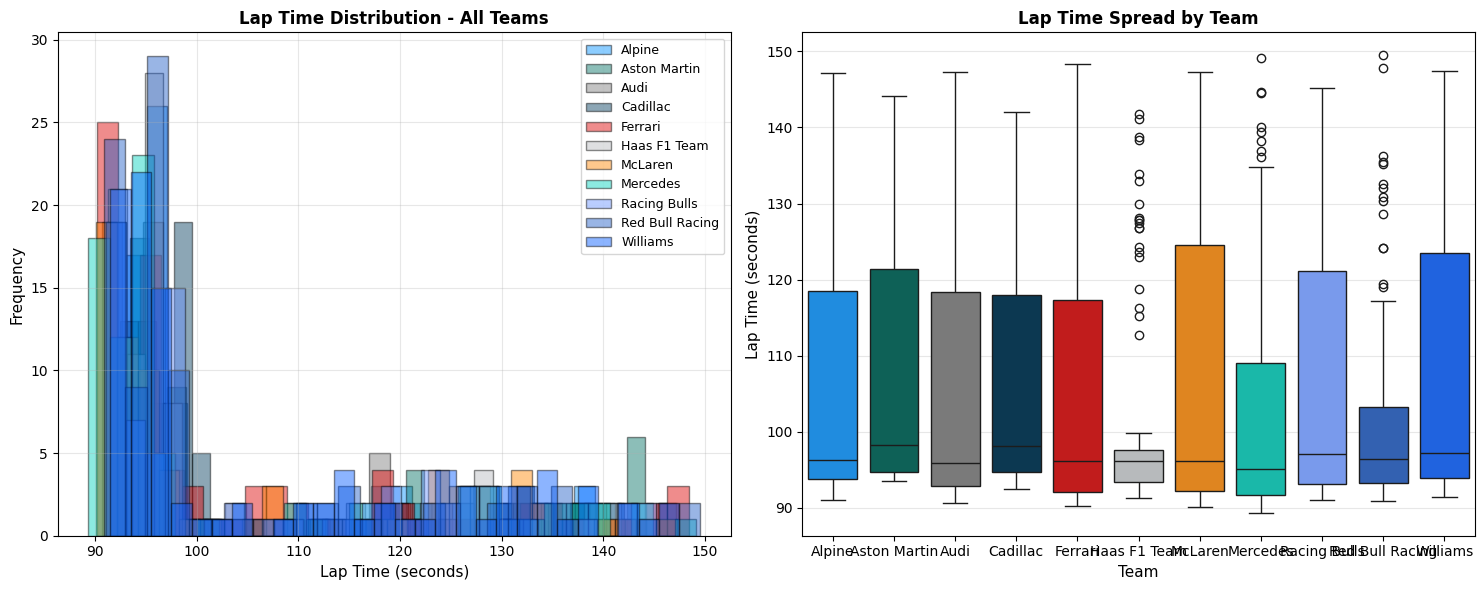

Team Lap Time Summary:
                 count     mean     min     std
Team                                           
Alpine              98  104.693  91.082  16.842
Aston Martin        57  108.506  93.485  17.919
Audi                82  105.495  90.658  17.370
Cadillac            76  105.570  92.503  15.542
Ferrari             89  105.422  90.229  17.383
Haas F1 Team        89  102.212  91.326  14.495
McLaren             77  106.046  90.133  17.657
Mercedes            81  103.246  89.362  17.599
Racing Bulls        78  106.408  91.097  16.193
Red Bull Racing     99  102.080  90.910  13.842
Williams           105  107.568  91.496  17.233


In [8]:
# Team-level lap time distribution for all teams
analysis_df = df.copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram by team
for team in sorted(df['Team'].dropna().unique().tolist()):
    team_laps = analysis_df[analysis_df['Team'] == team]['LapTime'].dropna()
    if not team_laps.empty:
        axes[0].hist(team_laps, bins=28, alpha=0.45, label=team, color=team_palette.get(team, 'gray'), edgecolor='black')

axes[0].set_xlabel('Lap Time (seconds)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Lap Time Distribution - All Teams', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Boxplot by team
box_data = analysis_df.copy()
sns.boxplot(data=box_data,x='Team', y='LapTime', hue='Team', palette=team_palette,
            order=sorted(box_data['Team'].dropna().unique().tolist()),ax=axes[1]
            )

axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time Spread by Team', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

team_summary = (analysis_df.groupby('Team')['LapTime'].agg(['count', 'mean', 'min', 'std'])
                .reindex(sorted(analysis_df['Team'].dropna().unique().tolist())).round(3)
                )

print('Team Lap Time Summary:')
print(team_summary)

### Laps Per Driver Distribution

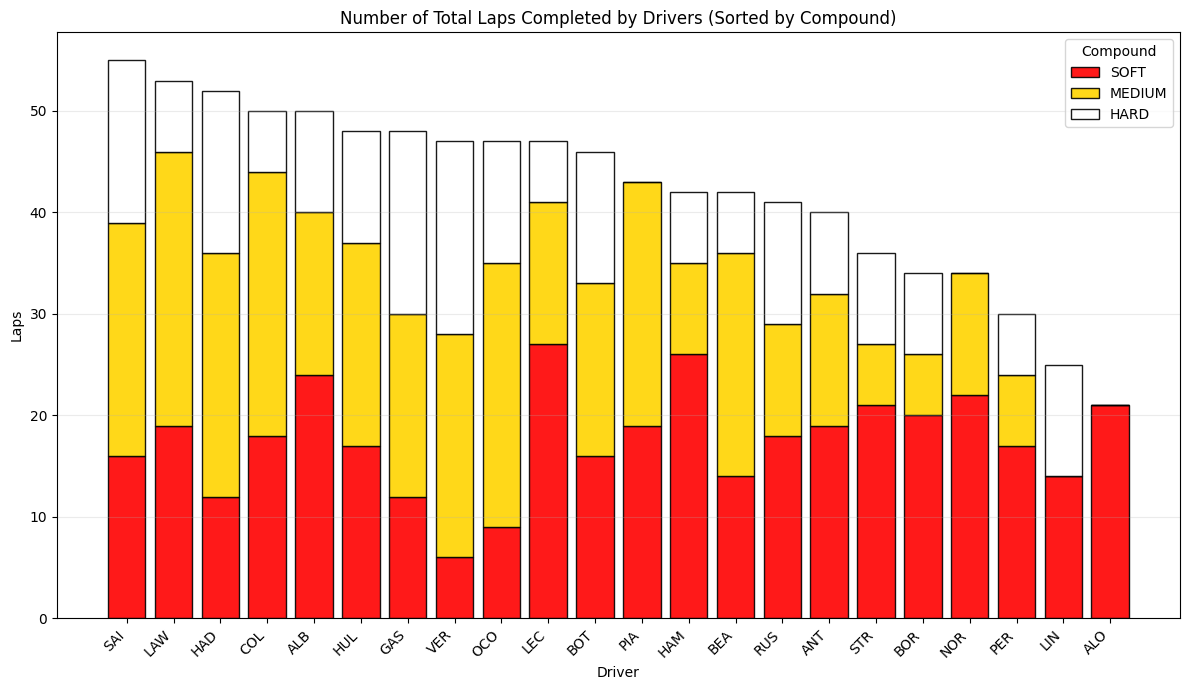

Laps completed by driver and compound (sorted):
Compound  SOFT  MEDIUM  HARD  TotalLaps
Driver                                 
SAI         16      23    16         55
LAW         19      27     7         53
HAD         12      24    16         52
COL         18      26     6         50
ALB         24      16    10         50
HUL         17      20    11         48
GAS         12      18    18         48
VER          6      22    19         47
OCO          9      26    12         47
LEC         27      14     6         47
BOT         16      17    13         46
PIA         19      24     0         43
HAM         26       9     7         42
BEA         14      22     6         42
RUS         18      11    12         41
ANT         19      13     8         40
STR         21       6     9         36
BOR         20       6     8         34
NOR         22      12     0         34
PER         17       7     6         30
LIN         14       0    11         25
ALO         21       0     0    

In [9]:
# Laps completed per driver, sorted by dominant compound
if 'Compound' in df.columns:
    compound_counts = (df.dropna(subset=['Driver', 'Compound'])
                       .assign(Compound=lambda x: x['Compound'].astype(str).str.upper())
                       .groupby(['Driver', 'Compound']).size().unstack(fill_value=0)
                       )

    # Keep compounds in a meaningful racing order first, then any extras
    preferred_compound_order = [c for c in ['SOFT', 'MEDIUM', 'HARD', 'INTER', 'WET'] if c in compound_counts.columns]
    remaining_compounds = sorted([c for c in compound_counts.columns if c not in preferred_compound_order])
    compound_order = preferred_compound_order + remaining_compounds
    compound_counts = compound_counts.reindex(columns=compound_order, fill_value=0)

    dominant_compound = compound_counts.idxmax(axis=1)
    order_df = pd.DataFrame({'Driver': compound_counts.index,
                             'DominantCompound': pd.Categorical(dominant_compound, categories=compound_order, ordered=True),
                             'TotalLaps': compound_counts.sum(axis=1)}).reset_index(drop=True)

    # Sort by dominant compound, then by total laps (descending)
    driver_order = order_df.sort_values(['TotalLaps'],ascending=[False])['Driver']
    compound_counts = compound_counts.loc[driver_order]

    plt.figure(figsize=(12, 7))
    bottom = np.zeros(len(compound_counts), dtype=float)

    for compound in compound_order:
        laps = compound_counts[compound].values
        plt.bar(compound_counts.index, laps, bottom=bottom, label=compound, color=tyre_palette.get(compound, '#CCCCCC'),
                edgecolor='black',alpha=0.9
                )
        bottom += laps

    plt.title('Number of Total Laps Completed by Drivers (Sorted by Compound)')
    plt.xlabel('Driver')
    plt.ylabel('Laps')
    plt.grid(alpha=0.25, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Compound')
    plt.tight_layout()
    plt.show()

    print('Laps completed by driver and compound (sorted):')
    print(compound_counts.assign(TotalLaps=compound_counts.sum(axis=1)).to_string())
else:
    # Fallback if compound data is unavailable
    laps_by_driver = df.groupby('Driver').size().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    colors = [driver_palette.get(driver, '#CCCCCC') for driver in laps_by_driver.index]
    plt.bar(laps_by_driver.index, laps_by_driver.values, color=colors, edgecolor='black', alpha=0.85)
    plt.title('Number of Total Laps Completed by Drivers')
    plt.xlabel('Driver')
    plt.ylabel('Laps')
    plt.grid(alpha=0.25, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('Laps completed by driver:')
    print(laps_by_driver.rename('Laps').to_string())

### Lap Time Trends by Session

Median lap-time traces by lap number show how pace evolves inside FP1, FP2, and FP3. Spikes and troughs usually reflect changes in run intention rather than pure car performance, so the session view helps separate recurring pace behavior from one-off operational noise.

FP3 is especially relevant because teams typically move closer to qualifying preparation, while FP1 and FP2 contain a broader mix of installation work, experimentation, and long-run programs.

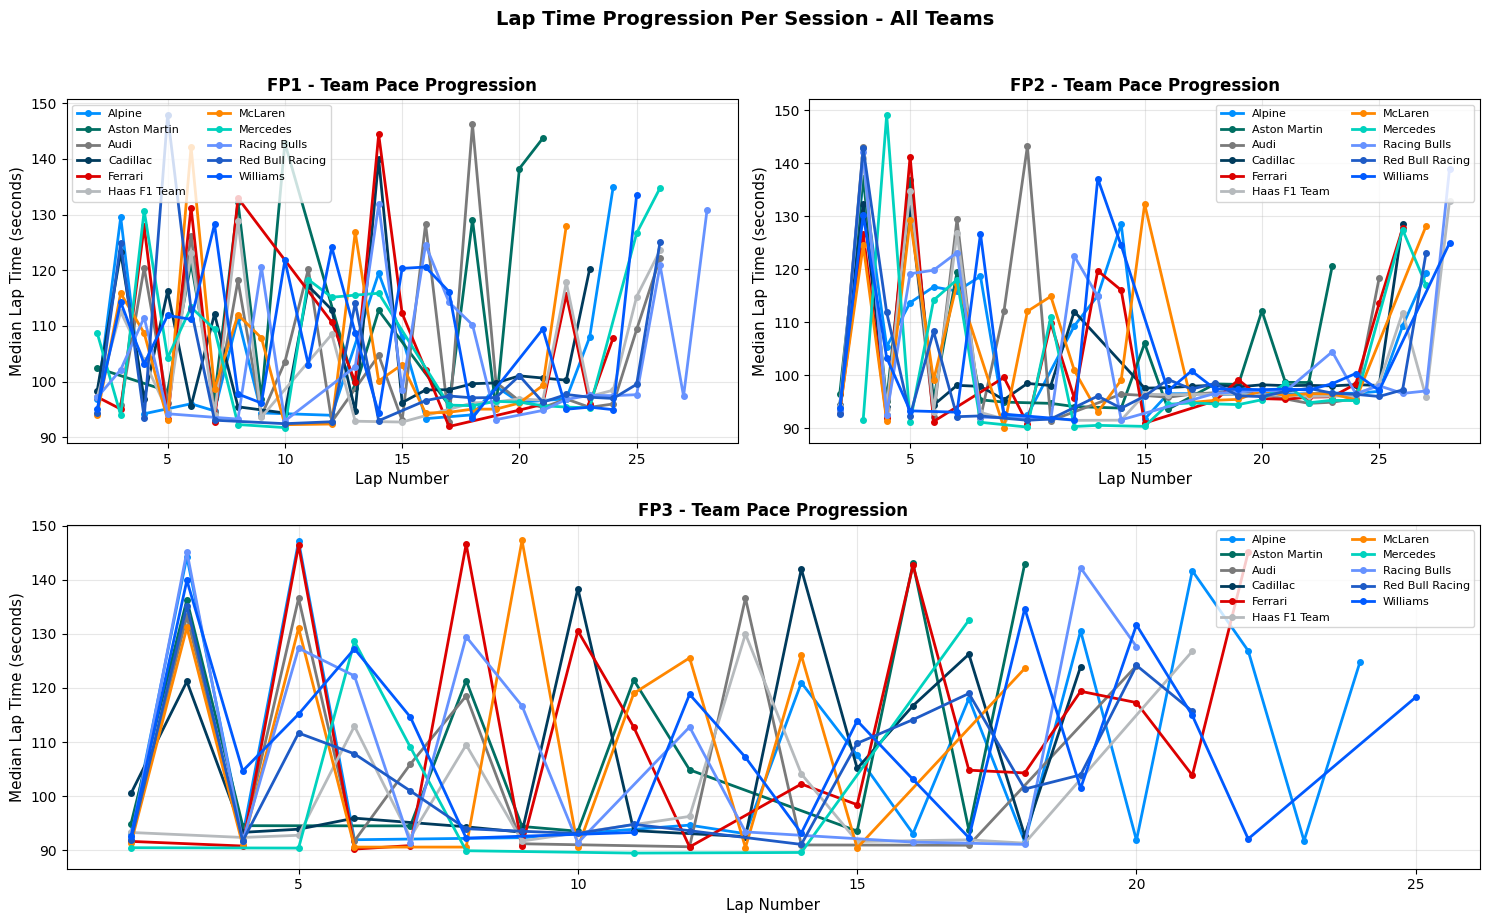

In [10]:
# Lap time progression by session and team (median pace by lap number)
layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(15, 9))

for session_name in session_names:
    ax = axes[session_name]
    session_df = df[df['Session'] == session_name].copy()
    for team in sorted(df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty:
            continue
        trend = (team_session.groupby('LapNumber', as_index=False)['LapTime'].median().sort_values('LapNumber'))
        ax.plot(trend['LapNumber'], trend['LapTime'], marker='o', linewidth=2, markersize=4, label=team,
                color=team_palette.get(team, 'gray')
                )
        
    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Median Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Team Pace Progression', fontsize=12, fontweight='bold')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)

plt.suptitle('Lap Time Progression Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Stint Pace Trends by Session

Averaging lap time by stint smooths some of the lap-to-lap volatility and makes each team's run structure easier to compare. These plots are best read as context-aware indicators: they combine tyre state, fuel load evolution, and execution quality rather than representing a pure ranking of intrinsic pace.

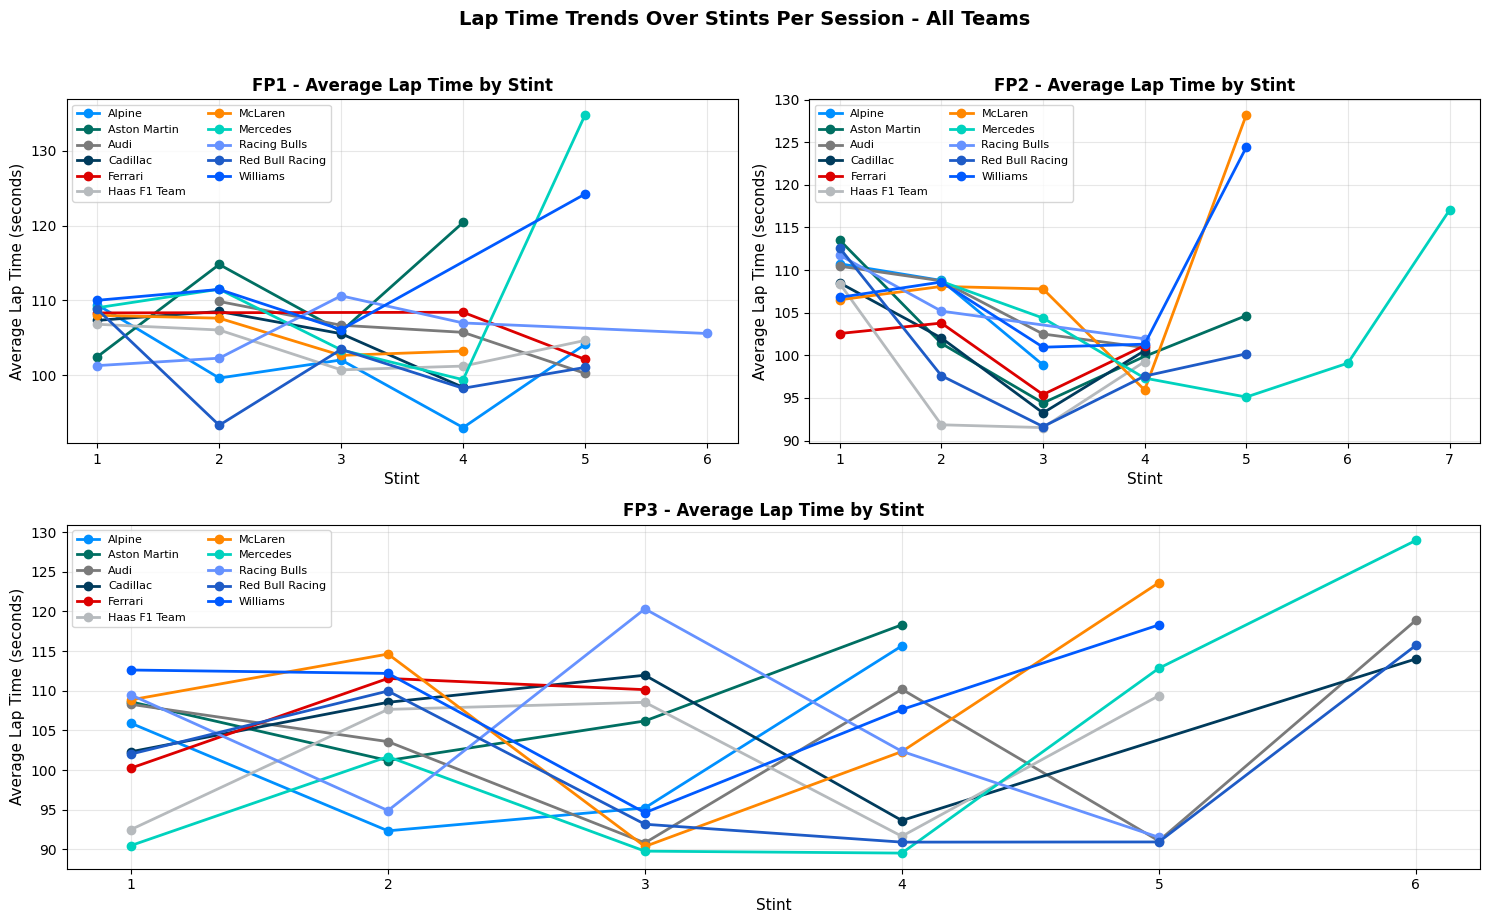

In [11]:
# Average lap time by stint for each session and team
layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(15, 9))

for session_name in session_names:
    ax = axes[session_name]
    session_df = df[df['Session'] == session_name].copy()
    for team in sorted(df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'Stint' not in team_session.columns:
            continue
        team_session = team_session.dropna(subset=['Stint', 'LapTime'])
        if team_session.empty:
            continue
        stint_avg = (team_session.groupby('Stint', as_index=False)['LapTime'].mean().sort_values('Stint'))
        ax.plot(stint_avg['Stint'], stint_avg['LapTime'], marker='o', linewidth=2, markersize=6, 
                color=team_palette.get(team, 'gray'), label=team
                )

    ax.set_xlabel('Stint', fontsize=11)
    ax.set_ylabel('Average Lap Time (seconds)', fontsize=11)
    ax.set_title(f'{session_name} - Average Lap Time by Stint', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle('Lap Time Trends Over Stints Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Speed Trap Trends by Session

Speed-trap traces add straight-line context to the lap-time story. Consistent top-end speed can indicate efficiency or deployment strength, but isolated slow points often come from traffic, lift-and-coast, pit-lane transitions, or non-push laps.

That makes SpeedST a useful feature, but not a standalone explanation for lap time. The strongest signal comes from how straight-line speed interacts with tyre state, session intent, and the rest of the lap.

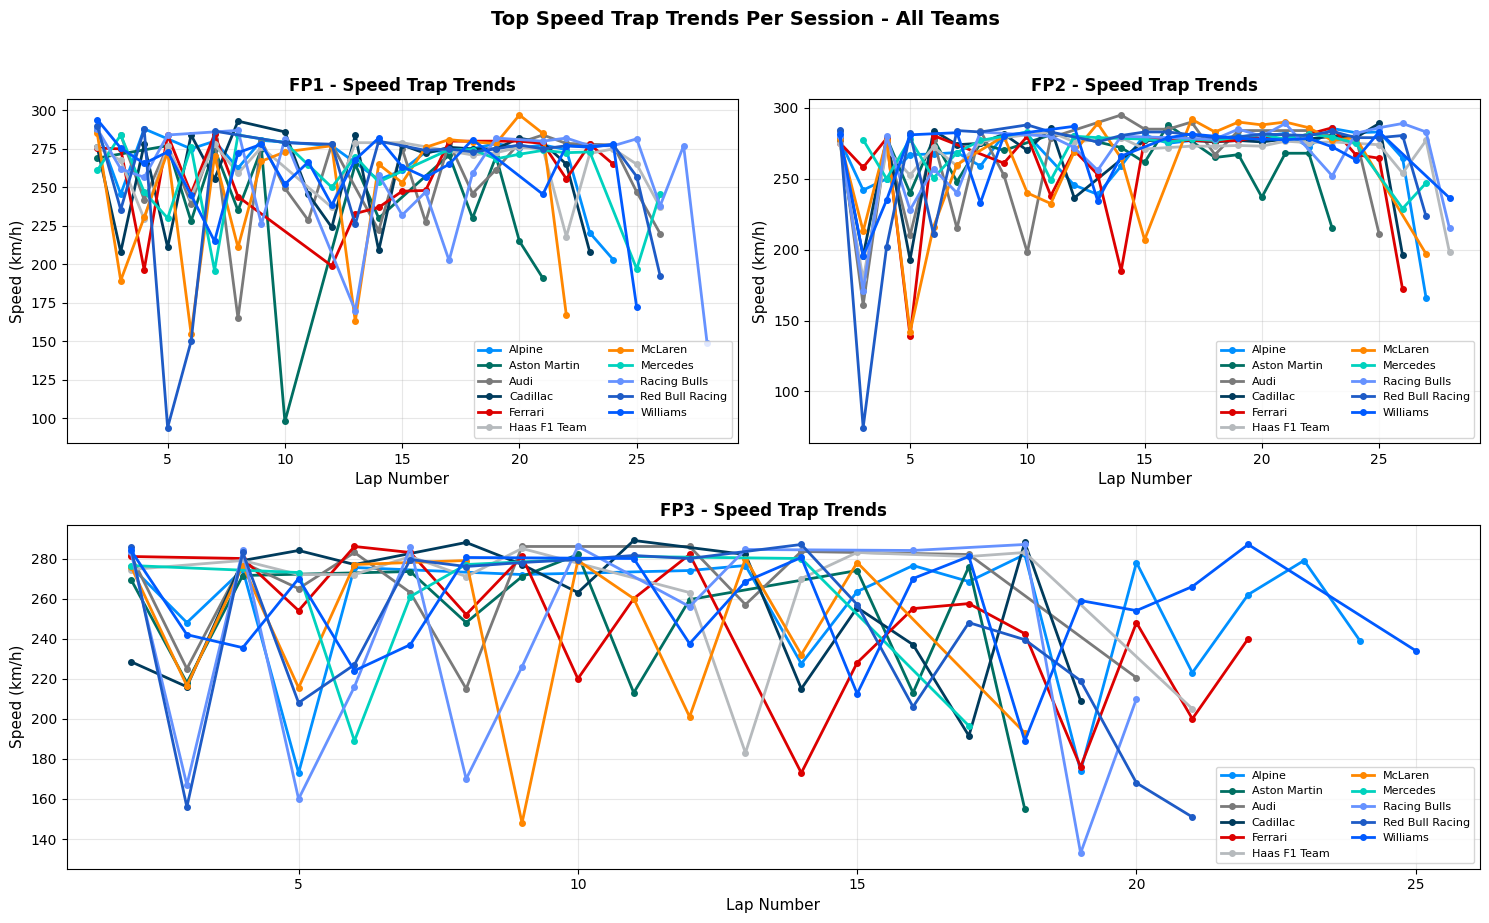

In [12]:
# Speed trap trends over sessions for all teams (median speed by lap number)
layout = [['FP1', 'FP2'], ['FP3', 'FP3']]
fig, axes = plt.subplot_mosaic(layout, figsize=(15, 9))

for session_name in session_names:
    ax = axes[session_name]
    session_df = df[df['Session'] == session_name].copy()
    for team in sorted(df['Team'].dropna().unique().tolist()):
        team_session = session_df[session_df['Team'] == team].copy()
        if team_session.empty or 'SpeedST' not in team_session.columns:
            continue
        speed_trend = (team_session.dropna(subset=['SpeedST']).groupby('LapNumber', as_index=False)['SpeedST'].median()
                       .sort_values('LapNumber')
                       )
        if speed_trend.empty:
            continue

        ax.plot(speed_trend['LapNumber'], speed_trend['SpeedST'], marker='o', linewidth=2, markersize=4, label=team,
                color=team_palette.get(team, 'gray')
                )

    ax.set_xlabel('Lap Number', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.set_title(f'{session_name} - Speed Trap Trends', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, ncol=2)

plt.suptitle('Top Speed Trap Trends Per Session - All Teams', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Telemetry and Track Map

This section compares the fastest available telemetry traces for all teams and overlays speed on the circuit map. The code intentionally skips missing or unreliable telemetry so the notebook can still run cleanly when a session pull does not return a full set of valid laps.

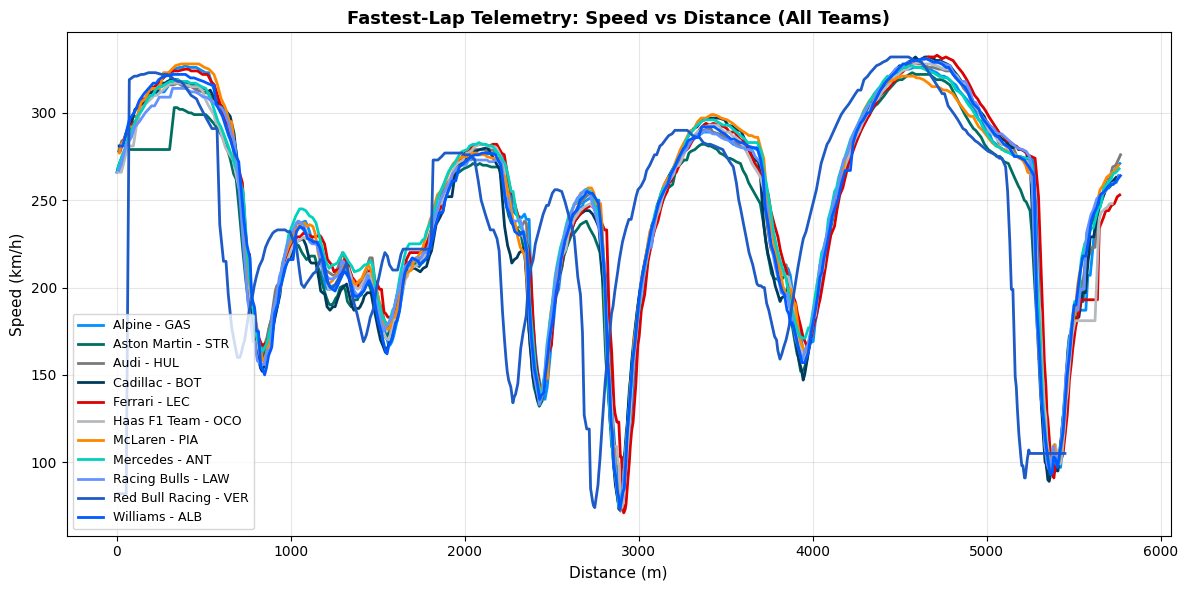

Telemetry fastest-lap summary:
           Team Driver Session  LapTimeSec
       Mercedes    ANT     FP3      89.362
        McLaren    PIA     FP2      90.133
        Ferrari    LEC     FP3      90.229
           Audi    HUL     FP3      90.658
Red Bull Racing    VER     FP3      90.910
         Alpine    GAS     FP3      91.082
   Racing Bulls    LAW     FP3      91.097
   Haas F1 Team    OCO     FP3      91.326
       Williams    ALB     FP2      91.496
       Cadillac    BOT     FP3      92.503
   Aston Martin    STR     FP3      93.485


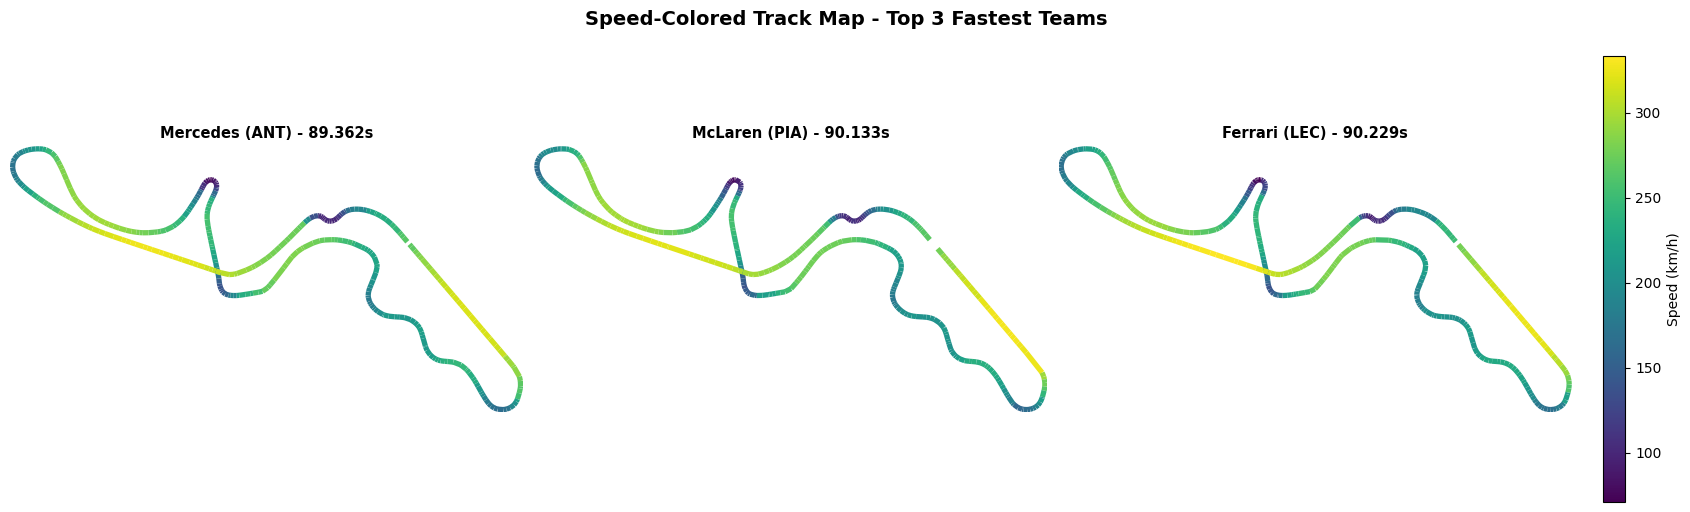

In [13]:
# Telemetry comparison and speed-colored track maps for fastest available laps
def lap_to_seconds(lap_time):
    return float(lap_time.total_seconds()) if pd.notna(lap_time) else np.nan

team_fastest = {}
for team in sorted(df['Team'].dropna().unique().tolist()):
    candidate_laps = []
    for session_name in session_names:
        session = sessions_by_name.get(session_name)
        if session is None:
            print(f"Session {session_name} not found in startup cache; skipping in telemetry block.")
            continue

        try:
            team_laps = session.laps.pick_teams(team).pick_quicklaps()
            if team_laps is None or len(team_laps) == 0:
                continue

            fastest = team_laps.pick_fastest()
            if fastest is not None and pd.notna(fastest['LapTime']):
                candidate_laps.append((session_name, fastest))
        except Exception as exc:
            print(f"Skipping {team} {session_name}: {exc}")

    if len(candidate_laps) == 0:
        print(f"No reliable telemetry lap found for {team} yet. Keeping logic for future reruns.")
        continue

    best_session, best_lap = min(candidate_laps, key=lambda item: item[1]['LapTime'])
    team_fastest[team] = {'session': best_session, 'lap': best_lap}

if len(team_fastest) == 0:
    print('No telemetry laps available to plot right now.')
else:
    # Speed vs distance telemetry traces
    fig, ax = plt.subplots(figsize=(12, 6))
    summary_rows = []

    for team, payload in team_fastest.items():
        lap = payload['lap']
        session_name = payload['session']
        try:
            telemetry = lap.get_car_data().add_distance()
            ax.plot(telemetry['Distance'], telemetry['Speed'], color=team_palette.get(team, 'gray'), linewidth=2,
                    label=f"{team} - {lap['Driver']}"
                    )
            summary_rows.append({'Team': team, 'Driver': lap['Driver'], 'Session': session_name, 
                                 'LapTimeSec': lap_to_seconds(lap['LapTime'])
                                 })
        except Exception as exc:
            print(f"Telemetry plot skipped for {team}: {exc}")

    ax.set_title('Fastest-Lap Telemetry: Speed vs Distance (All Teams)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Distance (m)', fontsize=11)
    ax.set_ylabel('Speed (km/h)', fontsize=11)
    ax.grid(alpha=0.3)
    if summary_rows:
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    if summary_rows:
        telemetry_summary = pd.DataFrame(summary_rows).sort_values('LapTimeSec').reset_index(drop=True)
        print('Telemetry fastest-lap summary:')
        print(telemetry_summary.to_string(index=False))

    # Track map colored by speed for the 3 fastest teams in one row
    map_data = {}
    for team, payload in team_fastest.items():
        lap = payload['lap']
        try:
            car = lap.get_car_data()[['Time', 'Speed']].copy().sort_values('Time')
            pos = lap.get_pos_data()[['Time', 'X', 'Y']].copy().sort_values('Time')

            if car.empty or pos.empty:
                print(f"Track map skipped for {team}: empty telemetry frames")
                continue

            merged = pd.merge_asof(pos, car, on='Time', direction='nearest')
            merged = merged.dropna(subset=['X', 'Y', 'Speed'])
            if len(merged) < 2:
                print(f"Track map skipped for {team}: insufficient merged telemetry points")
                continue

            map_data[team] = {'x': merged['X'].to_numpy(), 'y': merged['Y'].to_numpy(),
                              'speed': merged['Speed'].to_numpy(), 'driver': lap['Driver'],
                              'lap_time_sec': lap_to_seconds(lap['LapTime'])
                              }
        except Exception as exc:
            print(f"Track map skipped for {team}: {exc}")

    if len(map_data) == 0:
        print('No track-map telemetry available to draw right now.')
    else:
        top_teams = sorted(map_data.keys(), key=lambda t: map_data[t]['lap_time_sec'])[:3]

        n_teams = len(top_teams)
        fig, axes = plt.subplots(1, n_teams, figsize=(5.6 * n_teams, 5.2), constrained_layout=True)
        axes_flat = np.atleast_1d(axes).ravel()

        global_speed_min = min(map_data[t]['speed'].min() for t in top_teams)
        global_speed_max = max(map_data[t]['speed'].max() for t in top_teams)
        norm = plt.Normalize(global_speed_min, global_speed_max)

        for idx, team in enumerate(top_teams):
            ax = axes_flat[idx]
            x = map_data[team]['x']
            y = map_data[team]['y']
            speed = map_data[team]['speed']
            driver = map_data[team]['driver']

            points = np.array([x, y]).T.reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap='viridis', norm=norm)
            lc.set_array(speed[:-1])
            lc.set_linewidth(3.8)

            ax.add_collection(lc)
            ax.set_aspect('equal', 'box')
            ax.set_xlim(x.min() - 100, x.max() + 100)
            ax.set_ylim(y.min() - 100, y.max() + 100)
            ax.axis('off')
            ax.set_title(f"{team} ({driver}) - {map_data[team]['lap_time_sec']:.3f}s", fontsize=10.5, fontweight='bold')

        sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes_flat, fraction=0.03, pad=0.02, shrink=0.92)
        cbar.set_label('Speed (km/h)')

        fig.suptitle('Speed-Colored Track Map - Top 3 Fastest Teams', fontsize=14, fontweight='bold')
        plt.show()

### Tyre Compound Performance

Compound-level distributions show whether pace and consistency change when teams switch between SOFT, MEDIUM, and HARD tyres. Even when average lap time is similar, the spread can differ sharply because warm-up behavior, push-lap intent, and degradation profiles are not the same across compounds.

SOFT laps often contain both the strongest single-lap pace and some of the noisiest practice examples. That is why this notebook uses visual diagnostics and not just simple mean comparisons.

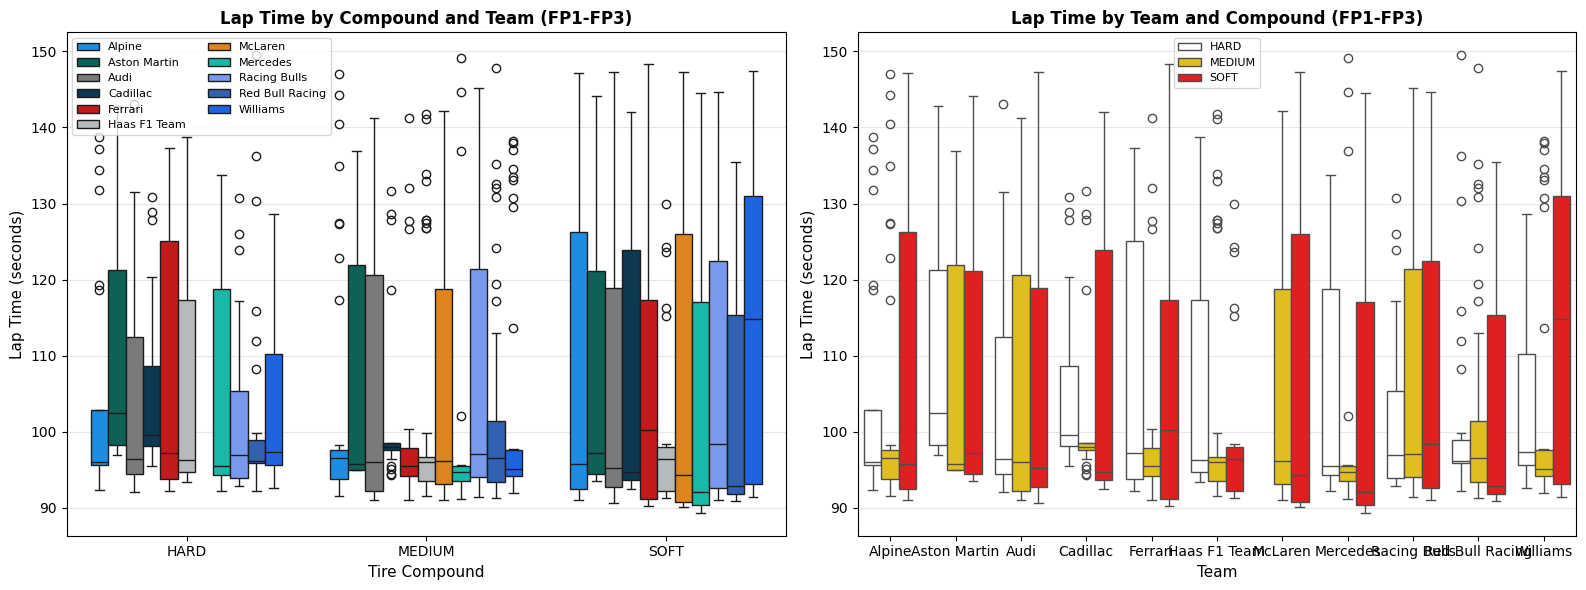

Average Lap Time by Team and Compound:
                             mean     std  count
Team            Compound                        
Alpine          HARD      104.109  15.871     24
                MEDIUM    102.066  15.340     44
                SOFT      109.014  19.237     30
Aston Martin    HARD      111.429  17.114      9
                MEDIUM    108.131  19.900      6
                SOFT      107.933  18.190     42
Audi            HARD      103.749  14.709     19
                MEDIUM    105.583  17.200     26
                SOFT      106.330  19.051     37
Cadillac        HARD      105.415  12.357     19
                MEDIUM    102.248  11.409     24
                SOFT      108.076  19.285     33
Ferrari         HARD      108.313  18.494     13
                MEDIUM    101.383  14.705     23
                SOFT      106.466  18.180     53
Haas F1 Team    HARD      105.768  16.263     18
                MEDIUM    101.792  14.896     48
                SOFT      100.

In [15]:
# Tire compound performance across all teams
practice_df = df[df['Session'].isin(session_names)].copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lap time by compound, segmented by team
compound_order = sorted([c for c in practice_df['Compound'].dropna().unique()])
sns.boxplot(data=practice_df[practice_df['Compound'].notna()], x='Compound', y='LapTime', hue='Team', order=compound_order,
            hue_order=sorted(box_data['Team'].dropna().unique().tolist()), palette=team_palette, ax=axes[0]
            )

axes[0].set_xlabel('Tire Compound', fontsize=11)
axes[0].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[0].set_title('Lap Time by Compound and Team (FP1-FP3)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
axes[0].legend(fontsize=8, ncol=2)

# Lap time by team, segmented by compound
team_order = sorted(practice_df['Team'].dropna().unique().tolist())
sns.boxplot(data=practice_df[practice_df['Compound'].notna()], x='Team', y='LapTime', hue='Compound', order=team_order,
            hue_order=compound_order, palette={c: tyre_palette.get(c, 'gray') for c in compound_order}, ax=axes[1]
            )

axes[1].set_xlabel('Team', fontsize=11)
axes[1].set_ylabel('Lap Time (seconds)', fontsize=11)
axes[1].set_title('Lap Time by Team and Compound (FP1-FP3)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Average Lap Time by Team and Compound:')
print(practice_df.groupby(['Team', 'Compound'])['LapTime'].agg(['mean', 'std', 'count']).round(3).sort_index())

## Machine Learning Analysis

This section builds supervised regression models to predict all-team lap time from lap context, tyre state, straight-line speed, and driver-team identifiers. Performance is evaluated with a baseline benchmark plus MAE, RMSE, and R2 on a held-out test split.

### Qualifying Model Pipeline

The pipeline keeps preprocessing and model fitting in one reproducible object. Numeric features are passed through directly, categorical variables are one-hot encoded, and ensemble regressors are trained on a filtered qualifying-oriented subset of the practice data.

The current implementation focuses the training set on SOFT-tyre laps marked as fresh-tyre runs, then rebalances session representation before fitting the models.

In [17]:
def qualifying_model_pipeline():
    print("Starting qualifying model pipeline")

    # Use all-team data and keep columns needed for modeling
    model_df = df.copy()

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    # Train only on soft-compound laps
    required_filter_cols = ['Compound']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    soft_mask = model_df['Compound'].astype(str).str.upper() == 'SOFT'
    model_df = model_df[soft_mask].copy()
    print(f"Rows after SOFT filter: {len(model_df)}")

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")

    # Define features and target (add telemetry/sector signals when available)
    base_num_features = ['LapNumber', 'TyreLife', 'Stint']
    base_cat_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    telemetry_candidate_features = ['SpeedST','SpeedI1', 'SpeedI2', 'SpeedFL', 'Throttle', 'Brake', 'DRS']

    telemetry_features = [
        col for col in telemetry_candidate_features
        if col in model_df.columns and pd.api.types.is_numeric_dtype(model_df[col])
    ]
    numeric_features = list(dict.fromkeys(base_num_features + telemetry_features))
    categorical_features = [col for col in base_cat_features if col in model_df.columns]
    features = numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = features + [target]
    model_df = model_df[required_cols].dropna().copy()

    # Split into features and target
    X = model_df[features].copy()
    y = model_df[target].copy()

    # One-hot encode categorical features
    preprocessor = ColumnTransformer(
        transformers=[('num', 'passthrough', numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                      ])

    print("Preprocessing pipeline created")

    # Use stratification only when every session has enough examples
    stratify_series = None
    session_counts = X['Session'].value_counts()
    if len(session_counts) > 1 and session_counts.min() >= 2:
        stratify_series = X['Session']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=324, stratify=stratify_series)

    # Baseline suite for validation context
    train_df = X_train.copy()
    train_df['LapTime'] = y_train.values
    test_df = X_test.copy().reset_index(drop=True)

    mean_baseline = DummyRegressor(strategy='mean')
    mean_baseline.fit(X_train[numeric_features], y_train)
    mean_baseline_predictions = mean_baseline.predict(X_test[numeric_features])
    mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
    mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
    mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

    # Create model pipelines
    rf_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('rf_regressor', RandomForestRegressor(n_estimators=300, min_samples_leaf=2, random_state=324))
               ])

    gb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('gb_regressor', GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, random_state=324))
               ])

    xgb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('xgb_regressor', XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=324, verbosity=0))
               ])

    # Train model and make predictions
    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Driver-level diagnostics: this helps choose the best model per driver, not only globally.
    driver_eval_df = X_test[['Driver', 'Team', 'Session']].copy().reset_index(drop=True)
    driver_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    driver_eval_df['RF_Pred'] = rf_predictions
    driver_eval_df['GB_Pred'] = gb_predictions
    driver_eval_df['XGB_Pred'] = xgb_predictions
    driver_eval_df['RF_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['RF_Pred']).abs()
    driver_eval_df['GB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['GB_Pred']).abs()
    driver_eval_df['XGB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['XGB_Pred']).abs()

    q_driver_mae = (driver_eval_df.groupby('Driver', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr']].mean()
                    .rename(columns={'RF_AbsErr': 'RF_MAE',
                                     'GB_AbsErr': 'GB_MAE',
                                     'XGB_AbsErr': 'XGB_MAE'
                                     }))

    q_driver_mae['BestModel'] = q_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].idxmin(axis=1).map({
        'RF_MAE': 'Random Forest Regression',
        'GB_MAE': 'Gradient Boosting Regression',
        'XGB_MAE': 'XGBoost Regression'
        })
    q_driver_mae['BestMAE'] = q_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].min(axis=1)
    q_driver_mae = q_driver_mae.sort_values('BestMAE').reset_index(drop=True)

    print("Model training completed")

    return {
        'q_model_df': model_df,
        'q_features': features,
        'q_X_train': X_train,
        'q_X_test': X_test,
        'q_y_train': y_train,
        'q_y_test': y_test,
        'q_mean_baseline_predictions': mean_baseline_predictions,
        'q_mean_baseline_mae': mean_baseline_mae,
        'q_mean_baseline_rmse': mean_baseline_rmse,
        'q_mean_baseline_r2': mean_baseline_r2,
        'q_rf_model': rf_model,
        'q_rf_predictions': rf_predictions,
        'q_rf_mae': rf_mae,
        'q_rf_rmse': rf_rmse,
        'q_rf_r2': rf_r2,
        'q_gb_model': gb_model,
        'q_gb_predictions': gb_predictions,
        'q_gb_mae': gb_mae,
        'q_gb_rmse': gb_rmse,
        'q_gb_r2': gb_r2,
        'q_xgb_model': xgb_model,
        'q_xgb_predictions': xgb_predictions,
        'q_xgb_mae': xgb_mae,
        'q_xgb_rmse': xgb_rmse,
        'q_xgb_r2': xgb_r2,
        'q_driver_eval_df': driver_eval_df,
        'q_driver_mae': q_driver_mae
    }

In [18]:
# Run the model pipeline
model_results = qualifying_model_pipeline()

# Extract results
q_model_df = model_results['q_model_df']
q_features = model_results['q_features']
q_X_train = model_results['q_X_train']
q_X_test = model_results['q_X_test']
q_y_train = model_results['q_y_train']
q_y_test = model_results['q_y_test']
q_mean_baseline_predictions = model_results['q_mean_baseline_predictions']
q_mean_baseline_mae = model_results['q_mean_baseline_mae']
q_mean_baseline_rmse = model_results['q_mean_baseline_rmse']
q_mean_baseline_r2 = model_results['q_mean_baseline_r2']
q_rf_model = model_results['q_rf_model']
q_rf_predictions = model_results['q_rf_predictions']
q_rf_mae = model_results['q_rf_mae']
q_rf_rmse = model_results['q_rf_rmse']
q_rf_r2 = model_results['q_rf_r2']
q_gb_model = model_results['q_gb_model']
q_gb_predictions = model_results['q_gb_predictions']
q_gb_mae = model_results['q_gb_mae']
q_gb_rmse = model_results['q_gb_rmse']
q_gb_r2 = model_results['q_gb_r2']
q_xgb_model = model_results['q_xgb_model']
q_xgb_predictions = model_results['q_xgb_predictions']
q_xgb_mae = model_results['q_xgb_mae']
q_xgb_rmse = model_results['q_xgb_rmse']
q_xgb_r2 = model_results['q_xgb_r2']
q_driver_eval_df = model_results['q_driver_eval_df']
q_driver_mae = model_results['q_driver_mae']

Starting qualifying model pipeline
Rows after SOFT filter: 311
Preprocessing pipeline created
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [19]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Mean Baseline','Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [q_mean_baseline_mae, q_rf_mae, q_gb_mae, q_xgb_mae],
    'Root Absolute Error (RMSE)': [q_mean_baseline_rmse, q_rf_rmse, q_gb_rmse, q_xgb_rmse],
    'R² Score': [q_mean_baseline_r2, q_rf_r2, q_gb_r2, q_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print("Qualifying Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Determine the best global model for reference.
if q_rf_r2 > q_gb_r2 and q_rf_r2 > q_xgb_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing global model for qualifying: {best_model}")
elif q_rf_r2 < q_gb_r2 and q_gb_r2 > q_xgb_r2:
    best_model = 'Gradient Boosting Regression'
    print(f"\nBest performing global model for qualifying: {best_model}")
elif q_xgb_r2 > q_rf_r2 and q_xgb_r2 > q_gb_r2:
    best_model = 'XGBoost Regression'
    print(f"\nBest performing global model for qualifying: {best_model}")
else:
    best_model = 'Tie'
    print("\nGlobal models have very similar R². No clear single best model.")

# Driver-level best model is often different from the global best model.
print("\nDriver-level best validation model (lower MAE is better):")
print(q_driver_mae[['Driver', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'BestModel', 'BestMAE']].sort_values('BestMAE')
      .to_string(index=False)
      )

Qualifying Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
               Mean Baseline                14.488 sec                 16.819 sec   -0.028
    Random Forest Regression                 4.019 sec                  6.123 sec    0.864
Gradient Boosting Regression                 3.862 sec                  5.868 sec    0.875
          XGBoost Regression                 3.886 sec                  6.006 sec    0.869

Best performing global model for qualifying: Gradient Boosting Regression

Driver-level best validation model (lower MAE is better):
Driver    RF_MAE    GB_MAE   XGB_MAE                    BestModel   BestMAE
   ALB  1.201153  0.255864  0.500437 Gradient Boosting Regression  0.255864
   VER  0.431639  0.320707  0.289553           XGBoost Regression  0.289553
   BEA  0.392038  0.373130  0.804076 Gradient Boosting Regression  0.373130
   ANT  1.263151  0.375737  0.505385 Gradient Boosting Regression  0.

#### Qualifying Model Performance Visualizations

The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

##### Metric Comparison

The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.

Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

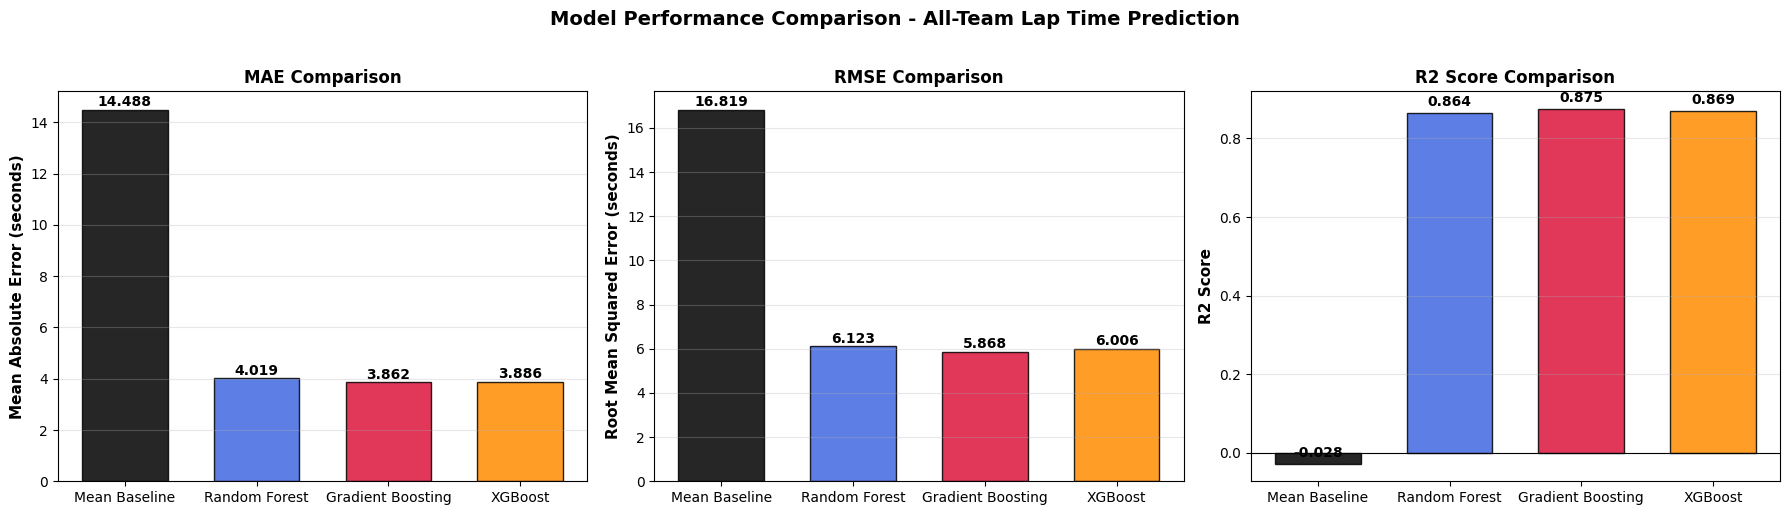

In [21]:
# Model Comparison for qualifying prediction
models = ['Mean Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
mae_scores = [ q_mean_baseline_mae, q_rf_mae, q_gb_mae, q_xgb_mae]
rmse_scores = [ q_mean_baseline_rmse, q_rf_rmse, q_gb_rmse, q_xgb_rmse]
r2_scores = [ q_mean_baseline_r2, q_rf_r2, q_gb_r2, q_xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
bar_colors = ['black', 'royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(models, mae_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(models, rmse_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison
axes[2].bar(models, r2_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - All-Team Lap Time Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

##### Residual Diagnostics

Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

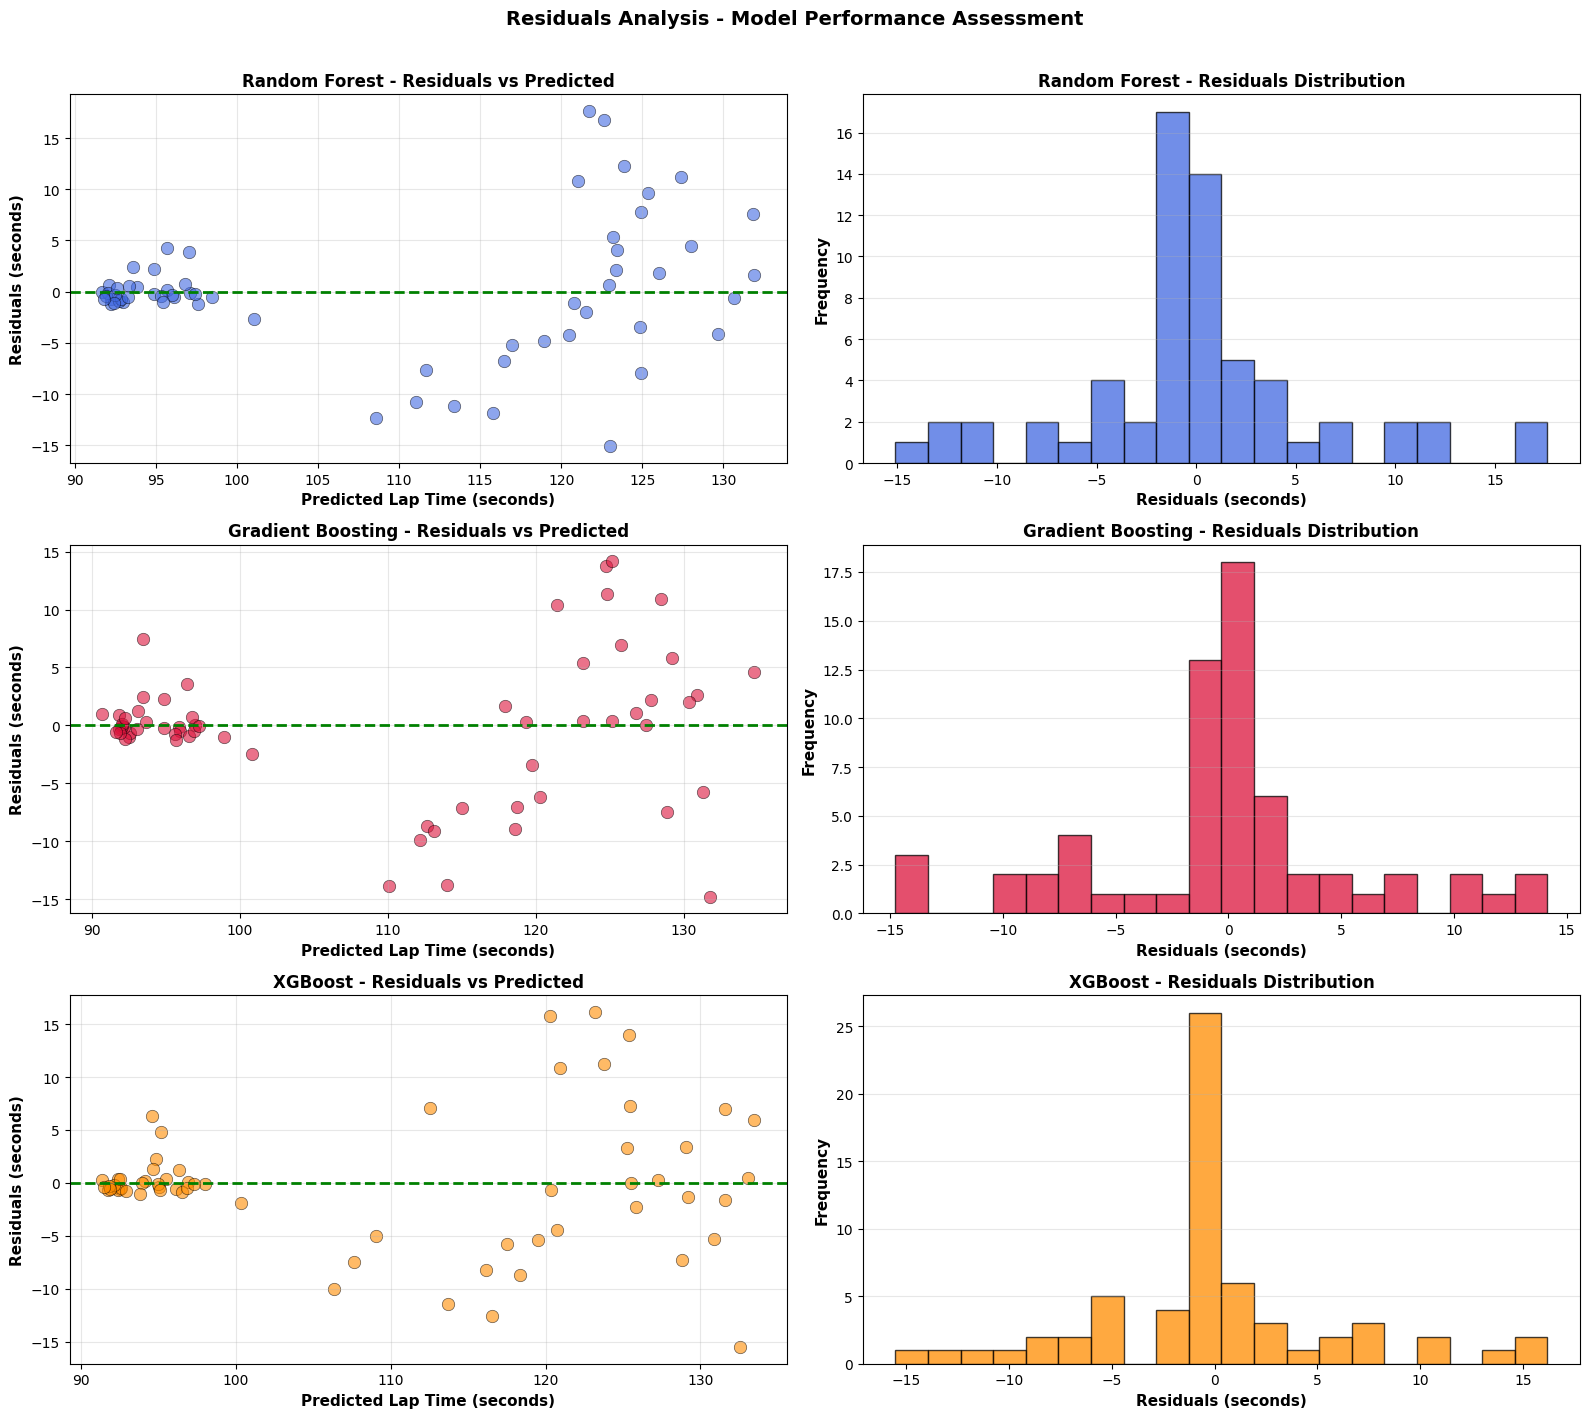

Random Forest - Mean Residuals: 0.0869, Std Dev: 6.1717
Gradient Boosting - Mean Residuals: -0.2278, Std Dev: 5.9107
XGBoost - Mean Residuals: -0.0689, Std Dev: 6.0534


In [22]:
# Residuals Analysis
rf_residuals = q_y_test - q_rf_predictions
gb_residuals = q_y_test - q_gb_predictions
xgb_residuals = q_y_test - q_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(q_rf_predictions, rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(q_gb_predictions, gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(q_xgb_predictions, xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {rf_residuals.mean():.4f}, Std Dev: {rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {gb_residuals.mean():.4f}, Std Dev: {gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {xgb_residuals.mean():.4f}, Std Dev: {xgb_residuals.std():.4f}")

##### Actual vs Predicted Fit

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

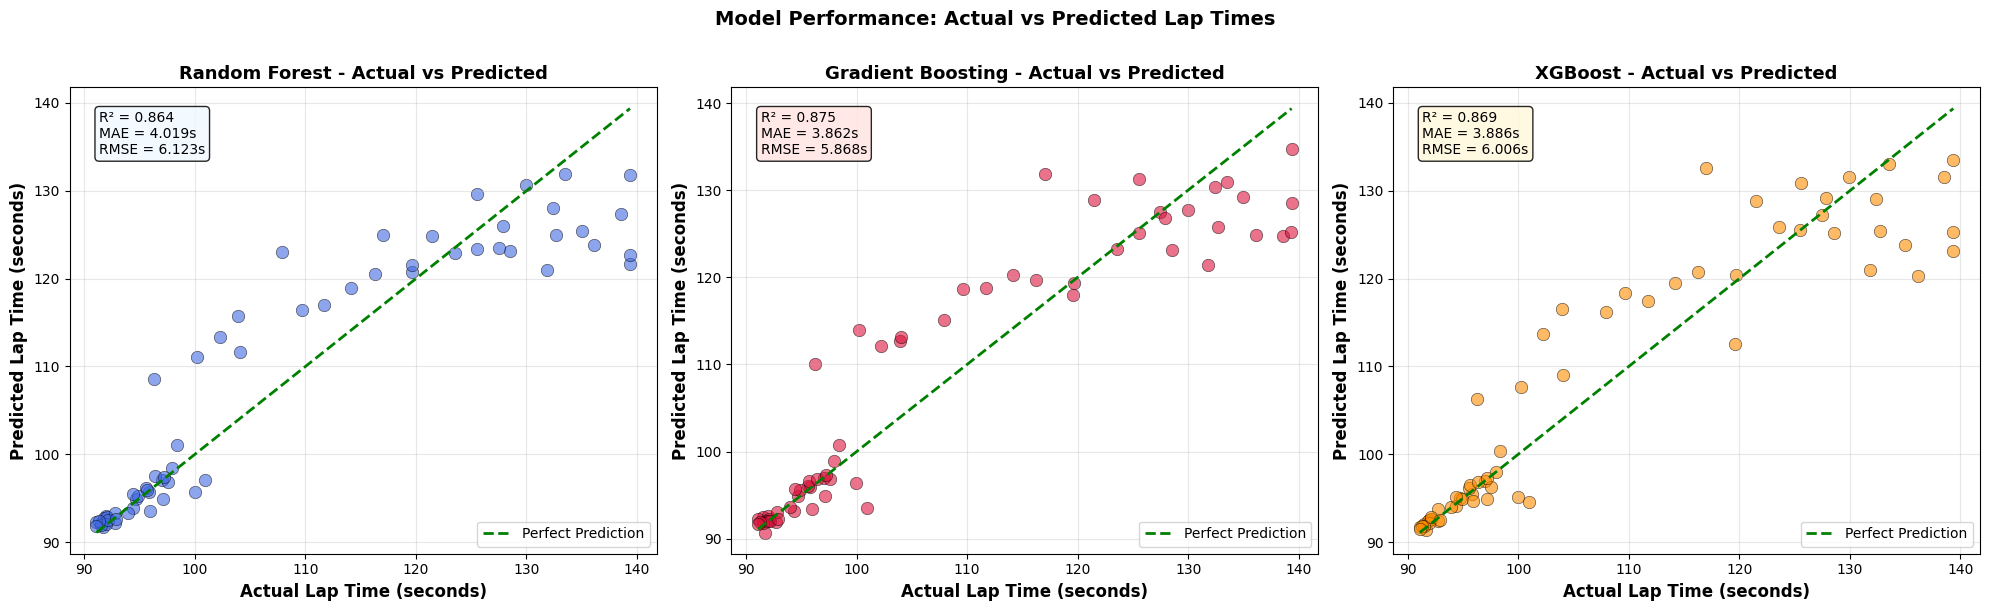

In [23]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(q_y_test, q_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {q_rf_r2:.3f}\nMAE = {q_rf_mae:.3f}s\nRMSE = {q_rf_rmse:.3f}s',
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(q_y_test, q_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'R² = {q_gb_r2:.3f}\nMAE = {q_gb_mae:.3f}s\nRMSE = {q_gb_rmse:.3f}s', 
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
             )

# XGBoost: Actual vs Predicted
axes[2].scatter(q_y_test, q_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([q_y_test.min(), q_y_test.max()], [q_y_test.min(), q_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(0.05, 0.95, f'R² = {q_xgb_r2:.3f}\nMAE = {q_xgb_mae:.3f}s\nRMSE = {q_xgb_rmse:.3f}s', 
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top', 
             bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
             )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Tyre Degradation Model Pipeline

In [24]:
def tyredeg_model_pipeline():
    print("Starting tyre degradation model pipeline")

    # Use all-team data and keep columns needed for modeling
    model_df = df.copy()

    # Reduce extreme outliers that hurt variance-based metrics like R^2
    low_q, high_q = model_df['LapTime'].quantile([0.05, 0.95])
    model_df = model_df[(model_df['LapTime'] >= low_q) & (model_df['LapTime'] <= high_q)].copy()

    # Validate required columns for tyre degradation analysis
    required_filter_cols = ['Compound', 'TyreLife']
    missing_filter_cols = [col for col in required_filter_cols if col not in model_df.columns]
    if missing_filter_cols:
        raise KeyError(f"Missing required filter column(s): {missing_filter_cols}")

    # Include ALL tyre compounds to study degradation patterns across compound types
    valid_compounds = ['SOFT', 'MEDIUM', 'HARD']
    compound_mask = model_df['Compound'].astype(str).str.upper().isin(valid_compounds)
    model_df = model_df[compound_mask].copy()
    print(f"Rows after compound filter (SOFT, MEDIUM, HARD): {len(model_df)}")
    print("Compound distribution:")
    print(model_df['Compound'].value_counts().to_string())

    if 'Session' not in model_df.columns:
        raise KeyError("Missing required column: Session")
    
    print("Session distribution:")
    print(model_df['Session'].value_counts().to_string())

    # Convert model inputs to stable numeric types before feature engineering
    for numeric_col in ['LapNumber', 'TyreLife', 'Stint']:
        if numeric_col in model_df.columns:
            model_df[numeric_col] = pd.to_numeric(model_df[numeric_col], errors='coerce')

    if 'FreshTyre' in model_df.columns:
        model_df['FreshTyre'] = model_df['FreshTyre'].fillna('Unknown').astype(str)

    # Define features and target
    telemetry_candidate_features = ['SpeedST', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'Throttle', 'Brake', 'DRS']
    telemetry_features = [
        col for col in telemetry_candidate_features
        if col in model_df.columns and pd.api.types.is_numeric_dtype(model_df[col])
    ]
    base_numeric_features = list(dict.fromkeys(['LapNumber', 'TyreLife', 'Stint'] + telemetry_features))
    categorical_features = ['Compound', 'Driver', 'Team', 'Session', 'TrackStatus']
    if 'FreshTyre' in model_df.columns:
        categorical_features.append('FreshTyre')

    features = base_numeric_features + categorical_features
    target = 'LapTime'

    # Keep rows where required columns exist and are non-null
    required_cols = base_numeric_features + categorical_features + [target]
    model_df = model_df[required_cols].dropna().copy()

    print(f"TyreLife range: {model_df['TyreLife'].min()} to {model_df['TyreLife'].max()}")

    # Split into features and target using driver-disjoint validation
    X = model_df[base_numeric_features + categorical_features].copy()
    y = model_df[target].copy()

    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=324)
    train_idx, test_idx = next(splitter.split(X, y, groups=X['Driver']))
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

    # Build train-only median baselines and target encodings
    train_df = X_train.copy()
    train_df['LapTime'] = y_train.values
    test_df = X_test.copy().reset_index(drop=True)
    X_train = train_df[features].copy()
    X_test = test_df[features].copy()

    preprocessor = ColumnTransformer(
        transformers=[('num', 'passthrough', base_numeric_features),
                      ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                      ])

    mean_baseline = DummyRegressor(strategy='mean')
    mean_baseline.fit(X_train[base_numeric_features], y_train)
    mean_baseline_predictions = mean_baseline.predict(X_test[base_numeric_features])
    mean_baseline_mae = mean_absolute_error(y_test, mean_baseline_predictions)
    mean_baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_baseline_predictions))
    mean_baseline_r2 = r2_score(y_test, mean_baseline_predictions)

    # Create model pipelines
    rf_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('rf_regressor', RandomForestRegressor(n_estimators=420, min_samples_leaf=1,
                                                      max_features='sqrt', random_state=324, n_jobs=-1))
                                                      ])

    gb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('gb_regressor', GradientBoostingRegressor(n_estimators=350, learning_rate=0.04,
                                                          subsample=0.85, random_state=324))
                                                          ])

    xgb_model = Pipeline(
        steps=[('preprocessor', preprocessor),
               ('xgb_regressor', XGBRegressor(n_estimators=600, learning_rate=0.03, max_depth=4,
                                              min_child_weight=3, subsample=0.9, colsample_bytree=0.9,
                                              reg_alpha=0.1, reg_lambda=1.2, random_state=324,
                                              verbosity=0, objective='reg:squarederror', tree_method='hist'))
                                              ])

    # Train model and make predictions
    print("Training Random Forest model")
    rf_model.fit(X_train, y_train)
    rf_predictions = rf_model.predict(X_test)

    print("Training Gradient Boosting model")
    gb_model.fit(X_train, y_train)
    gb_predictions = gb_model.predict(X_test)

    print("Training XGBoost model")
    xgb_model.fit(X_train, y_train)
    xgb_predictions = xgb_model.predict(X_test)

    # Calculate model metrics
    rf_mae = mean_absolute_error(y_test, rf_predictions)
    rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
    rf_r2 = r2_score(y_test, rf_predictions)

    gb_mae = mean_absolute_error(y_test, gb_predictions)
    gb_rmse = np.sqrt(mean_squared_error(y_test, gb_predictions))
    gb_r2 = r2_score(y_test, gb_predictions)

    xgb_mae = mean_absolute_error(y_test, xgb_predictions)
    xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
    xgb_r2 = r2_score(y_test, xgb_predictions)

    # Driver-level diagnostics: this helps choose the best model per driver, not only globally.
    driver_eval_df = X_test[['Driver', 'Team', 'Session']].copy().reset_index(drop=True)
    driver_eval_df['ActualLapTime'] = y_test.reset_index(drop=True)
    driver_eval_df['RF_Pred'] = rf_predictions
    driver_eval_df['GB_Pred'] = gb_predictions
    driver_eval_df['XGB_Pred'] = xgb_predictions
    driver_eval_df['RF_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['RF_Pred']).abs()
    driver_eval_df['GB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['GB_Pred']).abs()
    driver_eval_df['XGB_AbsErr'] = (driver_eval_df['ActualLapTime'] - driver_eval_df['XGB_Pred']).abs()

    t_driver_mae = (driver_eval_df.groupby('Driver', as_index=False)[['RF_AbsErr', 'GB_AbsErr', 'XGB_AbsErr']].mean()
                    .rename(columns={'RF_AbsErr': 'RF_MAE',
                                     'GB_AbsErr': 'GB_MAE',
                                     'XGB_AbsErr': 'XGB_MAE'
                                     }))

    t_driver_mae['BestModel'] = t_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].idxmin(axis=1).map({
        'RF_MAE': 'Random Forest Regression',
        'GB_MAE': 'Gradient Boosting Regression',
        'XGB_MAE': 'XGBoost Regression'
    })
    t_driver_mae['BestMAE'] = t_driver_mae[['RF_MAE', 'GB_MAE', 'XGB_MAE']].min(axis=1)
    t_driver_mae = t_driver_mae.sort_values('BestMAE').reset_index(drop=True)

    print("Model training completed")

    return {
        't_model_df': model_df,
        't_features': features,
        't_X_train': X_train,
        't_X_test': X_test,
        't_y_train': y_train,
        't_y_test': y_test,
        't_mean_baseline_predictions': mean_baseline_predictions,
        't_mean_baseline_mae': mean_baseline_mae,
        't_mean_baseline_rmse': mean_baseline_rmse,
        't_mean_baseline_r2': mean_baseline_r2,
        't_rf_model': rf_model,
        't_rf_predictions': rf_predictions,
        't_rf_mae': rf_mae,
        't_rf_rmse': rf_rmse,
        't_rf_r2': rf_r2,
        't_gb_model': gb_model,
        't_gb_predictions': gb_predictions,
        't_gb_mae': gb_mae,
        't_gb_rmse': gb_rmse,
        't_gb_r2': gb_r2,
        't_xgb_model': xgb_model,
        't_xgb_predictions': xgb_predictions,
        't_xgb_mae': xgb_mae,
        't_xgb_rmse': xgb_rmse,
        't_xgb_r2': xgb_r2,
        't_driver_eval_df': driver_eval_df,
        't_driver_mae': t_driver_mae
    }

In [25]:
# Run the model pipeline
model_results = tyredeg_model_pipeline()

# Extract results
t_model_df = model_results['t_model_df']
t_features = model_results['t_features']
t_X_train = model_results['t_X_train']
t_X_test = model_results['t_X_test']
t_y_train = model_results['t_y_train']
t_y_test = model_results['t_y_test']
t_mean_baseline_predictions = model_results['t_mean_baseline_predictions']
t_mean_baseline_mae = model_results['t_mean_baseline_mae']
t_mean_baseline_rmse = model_results['t_mean_baseline_rmse']
t_mean_baseline_r2 = model_results['t_mean_baseline_r2']
t_rf_model = model_results['t_rf_model']
t_rf_predictions = model_results['t_rf_predictions']
t_rf_mae = model_results['t_rf_mae']
t_rf_rmse = model_results['t_rf_rmse']
t_rf_r2 = model_results['t_rf_r2']
t_gb_model = model_results['t_gb_model']
t_gb_predictions = model_results['t_gb_predictions']
t_gb_mae = model_results['t_gb_mae']
t_gb_rmse = model_results['t_gb_rmse']
t_gb_r2 = model_results['t_gb_r2']
t_xgb_model = model_results['t_xgb_model']
t_xgb_predictions = model_results['t_xgb_predictions']
t_xgb_mae = model_results['t_xgb_mae']
t_xgb_rmse = model_results['t_xgb_rmse']
t_xgb_r2 = model_results['t_xgb_r2']
t_driver_mae = model_results['t_driver_mae']

Starting tyre degradation model pipeline
Rows after compound filter (SOFT, MEDIUM, HARD): 837
Compound distribution:
Compound
MEDIUM    328
SOFT      311
HARD      198
Session distribution:
Session
FP1    326
FP2    320
FP3    191
TyreLife range: 2.0 to 24.0
Training Random Forest model
Training Gradient Boosting model
Training XGBoost model
Model training completed


In [26]:
# Compare the performance of all trained models from the pipeline
perform_df = pd.DataFrame({
    'Model': ['Mean Baseline', 'Random Forest Regression', 'Gradient Boosting Regression' , 'XGBoost Regression'],
    'Mean Absolute Error (MAE)': [t_mean_baseline_mae, t_rf_mae, t_gb_mae, t_xgb_mae],
    'Root Absolute Error (RMSE)': [t_mean_baseline_rmse, t_rf_rmse, t_gb_rmse, t_xgb_rmse],
    'R² Score': [t_mean_baseline_r2, t_rf_r2, t_gb_r2, t_xgb_r2]
})
perform_df['Mean Absolute Error (MAE)'] = perform_df['Mean Absolute Error (MAE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['Root Absolute Error (RMSE)'] = perform_df['Root Absolute Error (RMSE)'].apply(lambda x: f"{x:,.3f} sec")
perform_df['R² Score'] = perform_df['R² Score'].apply(lambda x: f"{x:.3f}")

print("Tyre Degradation Pipeline Model Comparison:")
print(perform_df.to_string(index=False))

# Determine the best tyre degradation model.
if t_rf_r2 > t_gb_r2 and t_rf_r2 > t_xgb_r2:
    best_model = 'Random Forest Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_rf_r2 < t_gb_r2 and t_gb_r2 > t_xgb_r2:
    best_model = 'Gradient Boosting Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
elif t_xgb_r2 > t_rf_r2 and t_xgb_r2 > t_gb_r2:
    best_model = 'XGBoost Regression'
    print(f"\nBest performing model for predicting tyre degradation: {best_model}")
else:
    print("\nModels have the same R² score. No clear best model.")

# Driver-level best model is often different from the global best model.
print("\nDriver-level best validation model (lower MAE is better):")
print(t_driver_mae[['Driver', 'RF_MAE', 'GB_MAE', 'XGB_MAE', 'BestModel', 'BestMAE']].sort_values('BestMAE')
      .to_string(index=False)
      )

Tyre Degradation Pipeline Model Comparison:
                       Model Mean Absolute Error (MAE) Root Absolute Error (RMSE) R² Score
               Mean Baseline                12.422 sec                 14.485 sec   -0.001
    Random Forest Regression                 1.897 sec                  3.213 sec    0.951
Gradient Boosting Regression                 1.713 sec                  2.961 sec    0.958
          XGBoost Regression                 1.726 sec                  2.925 sec    0.959

Best performing model for predicting tyre degradation: XGBoost Regression

Driver-level best validation model (lower MAE is better):
Driver   RF_MAE   GB_MAE  XGB_MAE                BestModel  BestMAE
   PIA 1.879496 1.376897 1.305313       XGBoost Regression 1.305313
   OCO 2.081440 1.454507 1.343833       XGBoost Regression 1.343833
   COL 1.387316 1.548377 1.690768 Random Forest Regression 1.387316
   BOT 1.702586 2.036183 2.356635 Random Forest Regression 1.702586
   GAS 2.453000 2.083163 1.

#### Tyre Degradation Model Performance Visualizations

The performance visuals complement the printed metric table by showing error size, residual structure, and actual-versus-predicted alignment. Together they make it easier to judge whether a model is just numerically better or actually more reliable across the pace range.

##### Metric Comparison

The comparison charts summarize average error, sensitivity to larger misses, and explained variance. The printed table above includes Random Forest, Gradient Boosting, and XGBoost; the plots in this section focus on the main diagnostic comparisons used in the notebook output.

Lower MAE and RMSE, along with higher R2, indicate stronger predictive performance. The baseline mean predictor is included to confirm that the models are extracting genuine structure from the lap data.

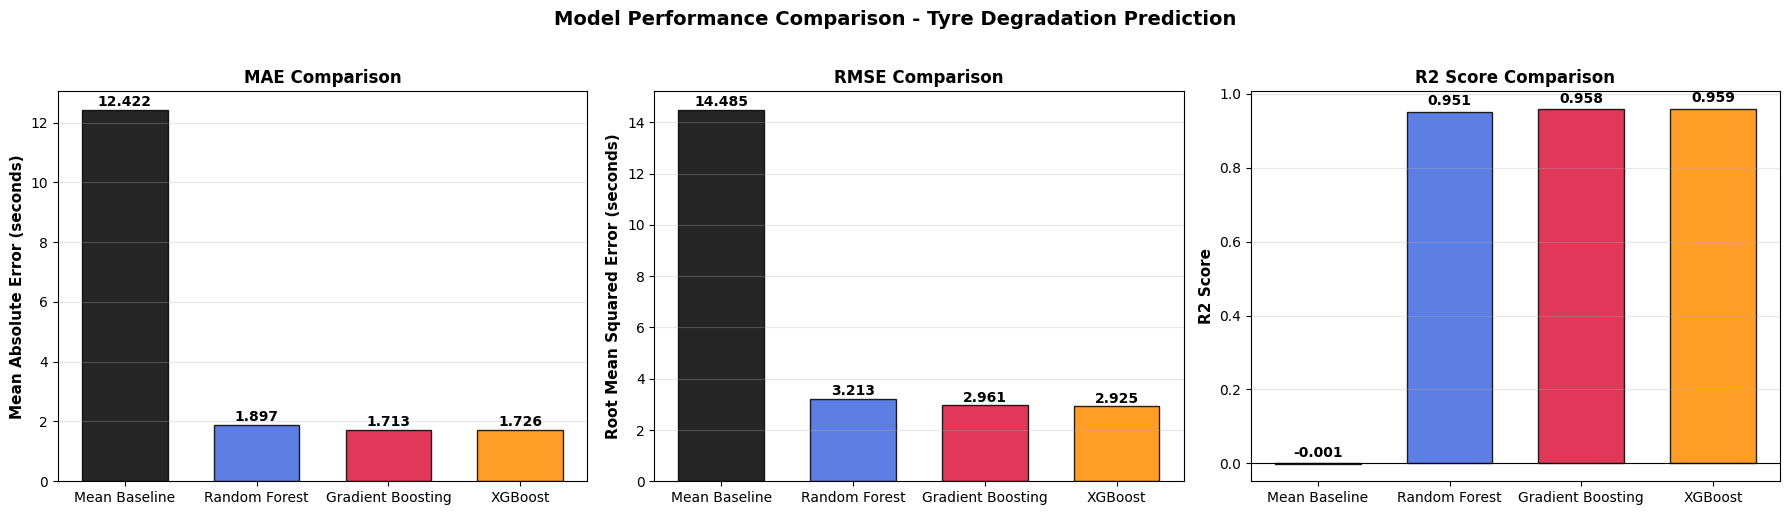

In [27]:
# Model Comparison for tyre degradation prediction
models = ['Mean Baseline', 'Random Forest', 'Gradient Boosting', 'XGBoost']
mae_scores = [t_mean_baseline_mae, t_rf_mae, t_gb_mae, t_xgb_mae]
rmse_scores = [t_mean_baseline_rmse, t_rf_rmse, t_gb_rmse, t_xgb_rmse]
r2_scores = [t_mean_baseline_r2, t_rf_r2, t_gb_r2, t_xgb_r2]

# Compare all trained models directly; keep baseline only for R² context
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bar_colors = ['black', 'royalblue', 'crimson', 'darkorange']

# MAE Comparison
axes[0].bar(models, mae_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[0].set_ylabel('Mean Absolute Error (seconds)', fontsize=11, fontweight='bold')
axes[0].set_title('MAE Comparison', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(mae_scores):
    axes[0].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# RMSE Comparison
axes[1].bar(models, rmse_scores, color=bar_colors, edgecolor='black', alpha=0.85, width=0.65)
axes[1].set_ylabel('Root Mean Squared Error (seconds)', fontsize=11, fontweight='bold')
axes[1].set_title('RMSE Comparison', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(rmse_scores):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# R2 Comparison (includes baseline)
colors_r2 = ['black', 'royalblue', 'crimson', 'darkorange', 'lightgray']
axes[2].bar(models, r2_scores, color=colors_r2, edgecolor='black', alpha=0.85, width=0.65)
axes[2].set_ylabel('R2 Score', fontsize=11, fontweight='bold')
axes[2].set_title('R2 Score Comparison', fontsize=12, fontweight='bold')
axes[2].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[2].grid(alpha=0.3, axis='y')
for i, v in enumerate(r2_scores):
    axes[2].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('Model Performance Comparison - Tyre Degradation Prediction', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

##### Residual Diagnostics

Residual plots show where prediction error stays centered and where it spreads out. A tight concentration around zero suggests the model is stable on representative laps, while heavy tails or skew indicate pace contexts the feature set still struggles to explain.

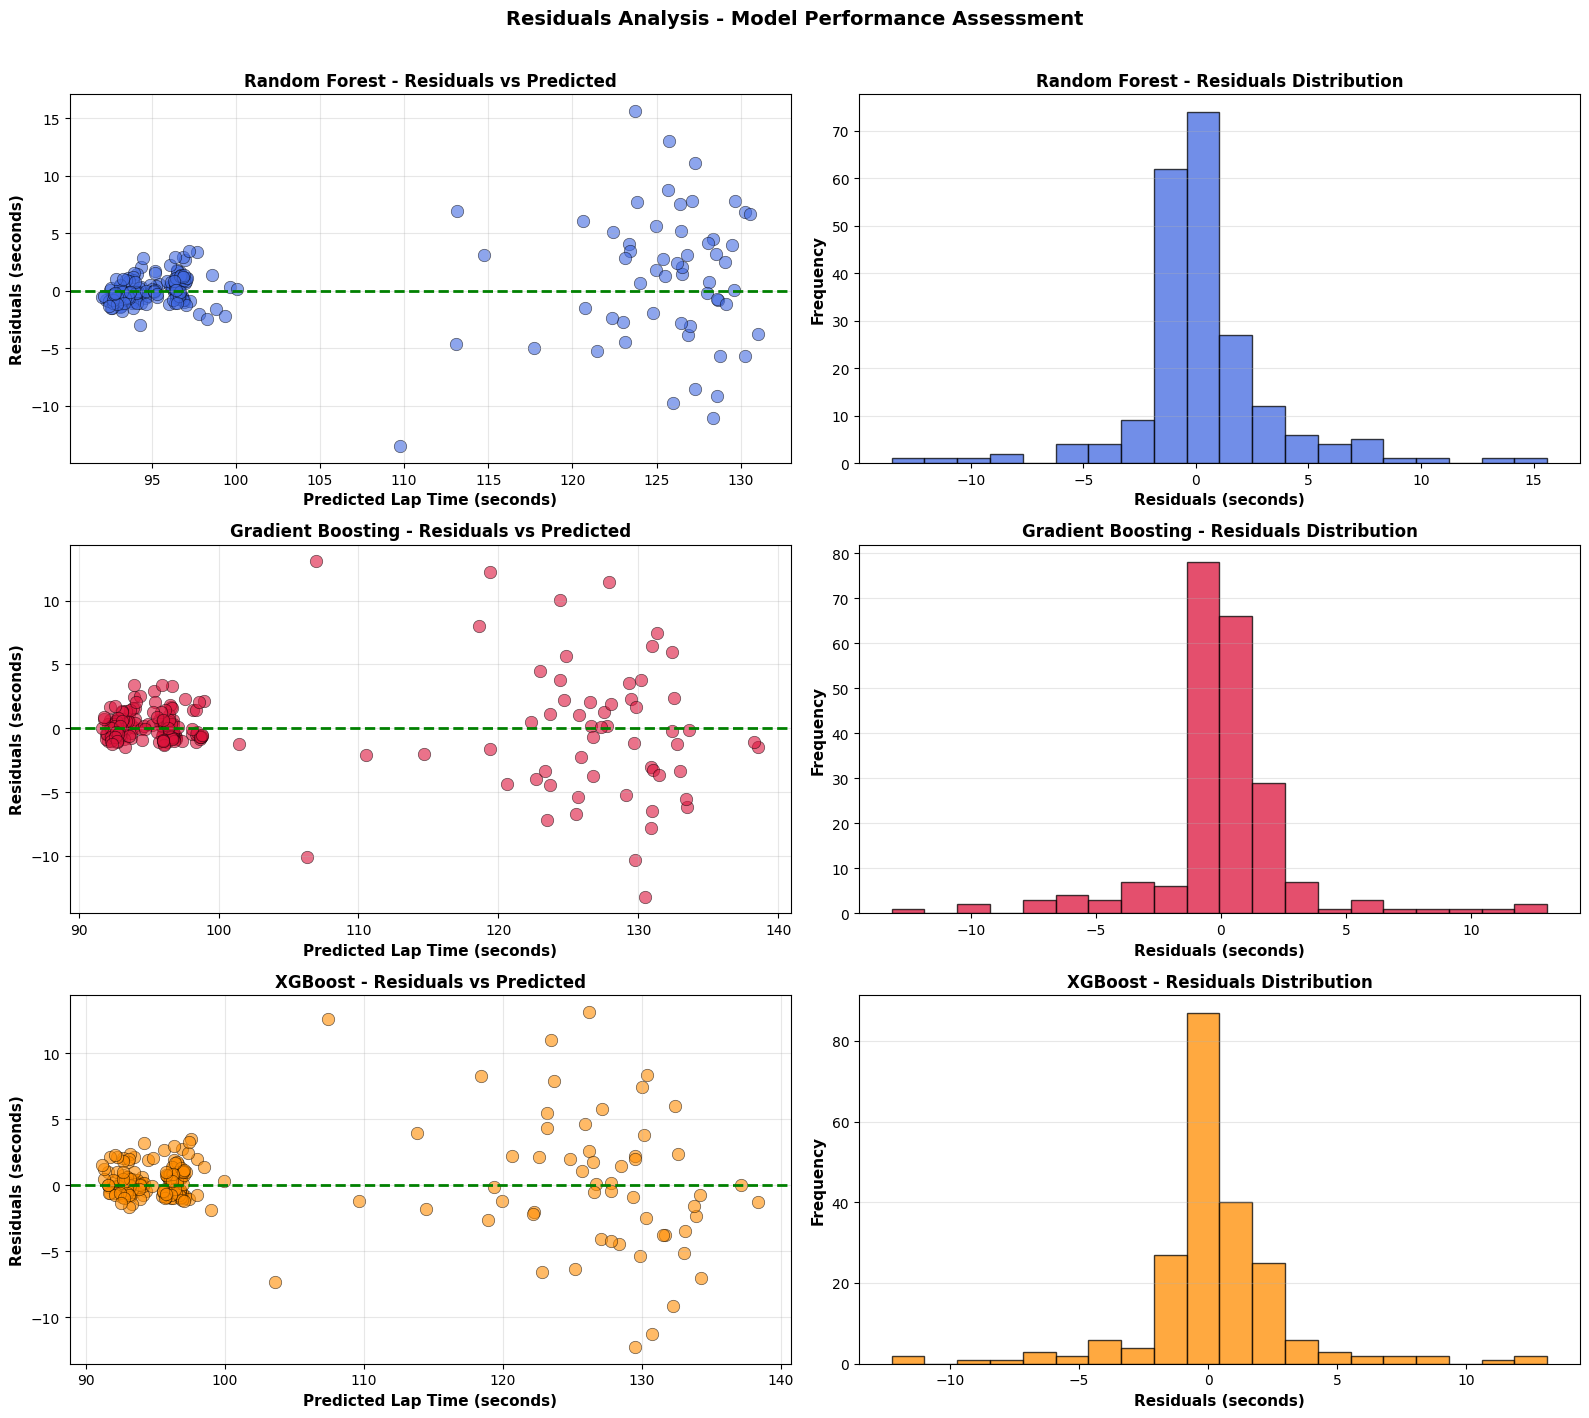

Random Forest - Mean Residuals: 0.3024, Std Dev: 3.2062
Gradient Boosting - Mean Residuals: 0.0410, Std Dev: 2.9671
XGBoost - Mean Residuals: 0.2428, Std Dev: 2.9220


In [28]:
# Residuals Analysis
t_rf_residuals = t_y_test - t_rf_predictions
t_gb_residuals = t_y_test - t_gb_predictions
t_xgb_residuals = t_y_test - t_xgb_predictions

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Random Forest - Residuals vs Predicted
axes[0, 0].scatter(t_rf_predictions, t_rf_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Random Forest - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Random Forest - Residuals Distribution
axes[0, 1].hist(t_rf_residuals, bins=20, alpha=0.75, color='royalblue', edgecolor='black')
axes[0, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Random Forest - Residuals Distribution', fontsize=12, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='y')

# Gradient Boosting - Residuals vs Predicted
axes[1, 0].scatter(t_gb_predictions, t_gb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Gradient Boosting - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Gradient Boosting - Residuals Distribution
axes[1, 1].hist(t_gb_residuals, bins=20, alpha=0.75, color='crimson', edgecolor='black')
axes[1, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Gradient Boosting - Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='y')

# XGBoost - Residuals vs Predicted
axes[2, 0].scatter(t_xgb_predictions, t_xgb_residuals, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2, 0].axhline(y=0, color='g', linestyle='--', lw=2)
axes[2, 0].set_xlabel('Predicted Lap Time (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 0].set_title('XGBoost - Residuals vs Predicted', fontsize=12, fontweight='bold')
axes[2, 0].grid(alpha=0.3)

# XGBoost - Residuals Distribution
axes[2, 1].hist(t_xgb_residuals, bins=20, alpha=0.75, color='darkorange', edgecolor='black')
axes[2, 1].set_xlabel('Residuals (seconds)', fontsize=11, fontweight='bold')
axes[2, 1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[2, 1].set_title('XGBoost - Residuals Distribution', fontsize=12, fontweight='bold')
axes[2, 1].grid(alpha=0.3, axis='y')

plt.suptitle('Residuals Analysis - Model Performance Assessment', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Random Forest - Mean Residuals: {t_rf_residuals.mean():.4f}, Std Dev: {t_rf_residuals.std():.4f}")
print(f"Gradient Boosting - Mean Residuals: {t_gb_residuals.mean():.4f}, Std Dev: {t_gb_residuals.std():.4f}")
print(f"XGBoost - Mean Residuals: {t_xgb_residuals.mean():.4f}, Std Dev: {t_xgb_residuals.std():.4f}")

##### Actual vs Predicted Fit

Actual-versus-predicted plots provide a direct visual check on calibration across the observed lap-time range. Points close to the diagonal indicate strong agreement, while systematic deviation or widening spread signals underfit regions, outliers, or missing context.

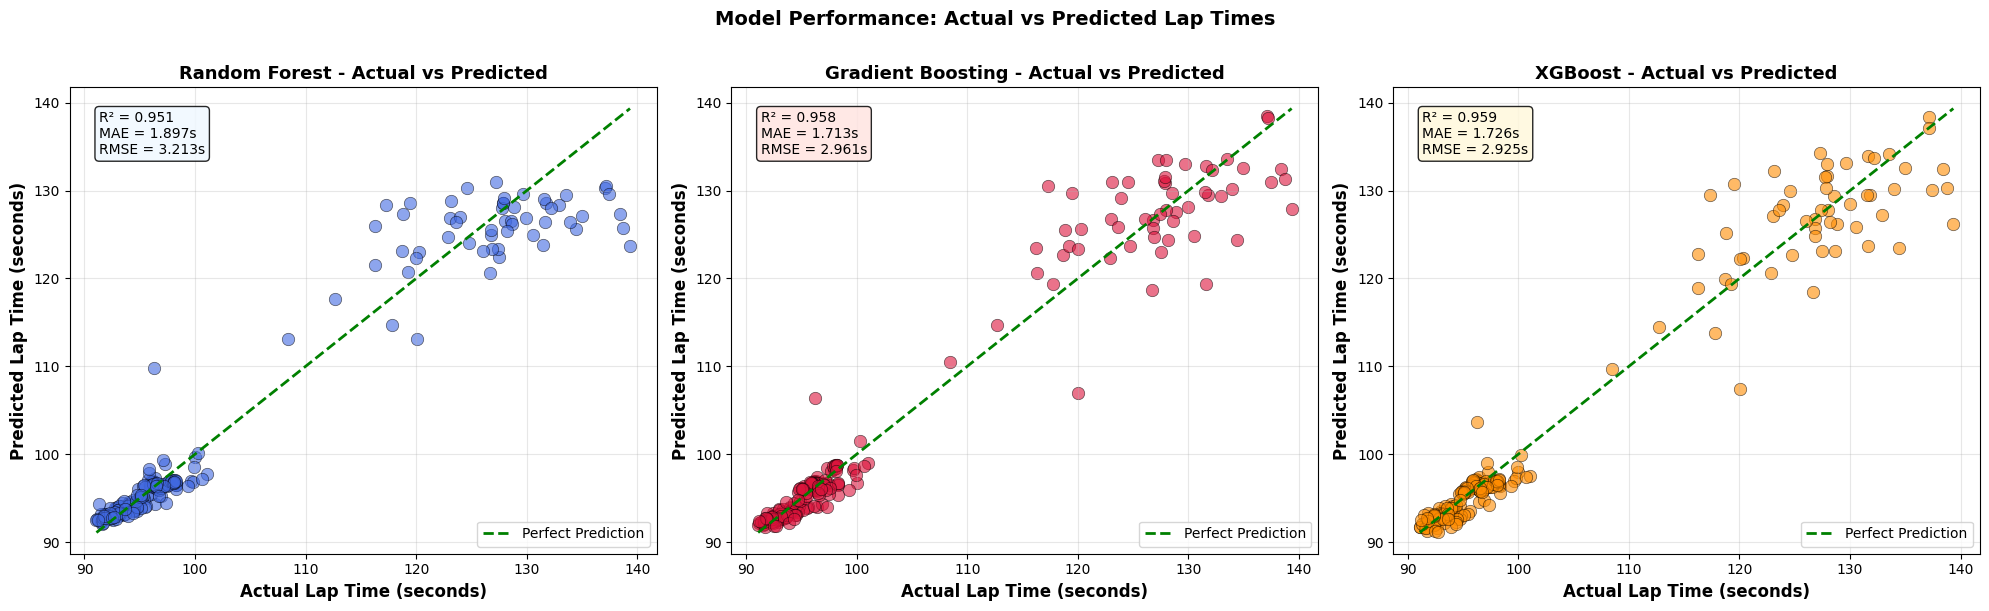

In [29]:
# Actual vs Predicted - Side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Random Forest: Actual vs Predicted
axes[0].scatter(t_y_test, t_rf_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='royalblue')
axes[0].plot([t_y_test.min(), t_y_test.max()], [t_y_test.min(), t_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[0].set_title('Random Forest - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].text(0.05, 0.95, f'R² = {t_rf_r2:.3f}\nMAE = {t_rf_mae:.3f}s\nRMSE = {t_rf_rmse:.3f}s', 
             transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='aliceblue', alpha=0.85)
             )

# Gradient Boosting: Actual vs Predicted
axes[1].scatter(t_y_test, t_gb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='crimson')
axes[1].plot([t_y_test.min(), t_y_test.max()], [t_y_test.min(), t_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[1].set_title('Gradient Boosting - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].text(0.05, 0.95, f'R² = {t_gb_r2:.3f}\nMAE = {t_gb_mae:.3f}s\nRMSE = {t_gb_rmse:.3f}s',
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.85)
             )

# XGBoost: Actual vs Predicted
axes[2].scatter(t_y_test, t_xgb_predictions, alpha=0.6, s=80, edgecolors='black', linewidths=0.5, color='darkorange')
axes[2].plot([t_y_test.min(), t_y_test.max()], [t_y_test.min(), t_y_test.max()], 'g--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Predicted Lap Time (seconds)', fontsize=12, fontweight='bold')
axes[2].set_title('XGBoost - Actual vs Predicted', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)
axes[2].grid(alpha=0.3)
axes[2].text(0.05, 0.95, f'R² = {t_xgb_r2:.3f}\nMAE = {t_xgb_mae:.3f}s\nRMSE = {t_xgb_rmse:.3f}s',
             transform=axes[2].transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='cornsilk', alpha=0.85)
             )

plt.suptitle('Model Performance: Actual vs Predicted Lap Times', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Qualifying Pace Projection

This scenario section uses each driver's best validation model (with a global fallback) to estimate how qualifying-style lap time changes as tyre life increases under controlled assumptions.

Treat the output as a sensitivity study rather than an exact forecast. It is most useful for comparing relative driver and team behavior under the same modeled conditions.

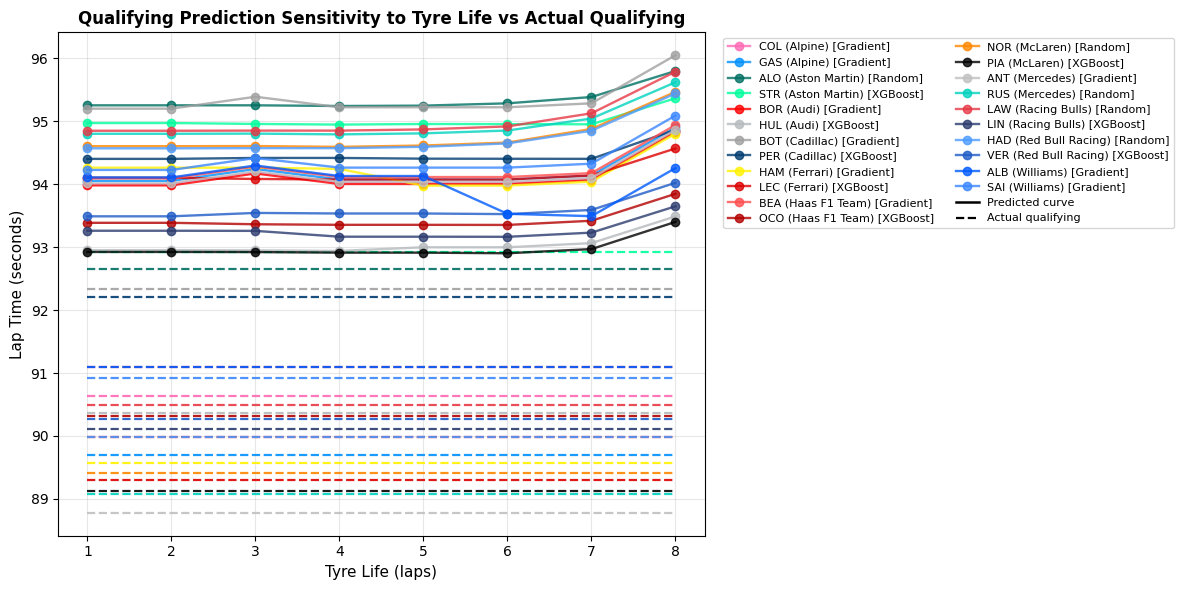

Global Qualifying fallback model: Gradient Boosting Regression
Drivers with personalized model selection: 20
Best predicted qualifying lap by driver:
           Team Driver  TyreLife  PredictedLapTimeSec PredictedLapTime  LapTimeSec ActualLapTime                    ModelUsed
        McLaren    PIA         6            92.903069         1:32.903      89.132      1:29.132           XGBoost Regression
           Audi    HUL         4            92.940369         1:32.940      90.358      1:30.358           XGBoost Regression
   Racing Bulls    LIN         6            93.164459         1:33.164      90.109      1:30.109           XGBoost Regression
   Haas F1 Team    OCO         6            93.353210         1:33.353      90.309      1:30.309           XGBoost Regression
Red Bull Racing    VER         2            93.490036         1:33.490      90.262      1:30.262           XGBoost Regression
       Williams    ALB         7            93.492395         1:33.492      91.088      1:31.0

In [35]:
# Format lap time in minutes:seconds.milliseconds
def format_lap_time(seconds: float) -> str:
    mins = int(seconds // 60)
    secs = seconds - mins * 60
    return f"{mins}:{secs:06.3f}"

# Build global and driver-level model mapping
model_lookup = {'Random Forest Regression': q_rf_model,
                'Gradient Boosting Regression': q_gb_model,
                'XGBoost Regression': q_xgb_model
                }

if q_rf_r2 >= q_gb_r2 and q_rf_r2 >= q_xgb_r2:
    global_model_name = 'Random Forest Regression'
elif q_gb_r2 >= q_rf_r2 and q_gb_r2 >= q_xgb_r2:
    global_model_name = 'Gradient Boosting Regression'
else:
    global_model_name = 'XGBoost Regression'

global_model = model_lookup[global_model_name]

driver_best_model = {}
if 'q_driver_mae' in globals() and isinstance(q_driver_mae, pd.DataFrame) and not q_driver_mae.empty:
    driver_best_model = dict(zip(q_driver_mae['Driver'], q_driver_mae['BestModel']))

# Use the most common track status as a qualifying-simulation default
if 'TrackStatus' in df.columns and df['TrackStatus'].notna().any():
    default_track_status = df['TrackStatus'].mode().iloc[0]
else:
    default_track_status = 1

# Build one representative row per driver from the all-team practice data
driver_profile = (df.groupby('Driver', as_index=False).agg({
                    'Team': lambda x: x.mode().iloc[0],
                    'LapNumber': 'median',
                    'Stint': 'median',
                    'SpeedFL': 'median',
                    'Compound': lambda x: x.mode().iloc[0]
                    }))

driver_profile = driver_profile.copy()

tyre_life_range = list(range(1, 9))
sensitivity_rows = []

for _, row in driver_profile.iterrows():
    for tyre_life in tyre_life_range:
        sensitivity_rows.append({'LapNumber': int(round(row['LapNumber'])), 
                                 'TyreLife': tyre_life,
                                 'Stint': int(round(row['Stint'])),
                                 'SpeedFL': float(row['SpeedFL']),
                                 'TrackStatus': default_track_status,
                                 'Compound': 'SOFT',
                                 'Driver': row['Driver'],
                                 'Team': row['Team'],
                                 'Session': 'Q'
                                 })

sensitivity_df = pd.DataFrame(sensitivity_rows)

# Add the same simple training-baseline encodings used by the degradation model
global_median = float(df['LapTime'].median())
driver_median = df.groupby('Driver')['LapTime'].median()
team_median = df.groupby('Team')['LapTime'].median()
compound_median = df.groupby('Compound')['LapTime'].median()
driver_compound_median = df.groupby(['Driver', 'Compound'])['LapTime'].median()
team_compound_median = df.groupby(['Team', 'Compound'])['LapTime'].median()

def lookup_pair(series_a, series_b, lookup_series):
    return pd.Series(
        [lookup_series.get((a, b), np.nan) for a, b in zip(series_a, series_b)],
        index=series_a.index
    )

sensitivity_df['DriverMedianLapTime'] = sensitivity_df['Driver'].map(driver_median).fillna(global_median)
sensitivity_df['TeamMedianLapTime'] = sensitivity_df['Team'].map(team_median).fillna(global_median)
sensitivity_df['CompoundMedianLapTime'] = sensitivity_df['Compound'].map(compound_median).fillna(global_median)
sensitivity_df['DriverCompoundMedianLapTime'] = lookup_pair(sensitivity_df['Driver'],
                                                            sensitivity_df['Compound'],
                                                            driver_compound_median
        ).fillna(sensitivity_df['DriverMedianLapTime']).fillna(sensitivity_df['CompoundMedianLapTime']).fillna(global_median)
sensitivity_df['TeamCompoundMedianLapTime'] = lookup_pair(sensitivity_df['Team'],
                                                          sensitivity_df['Compound'],
                                                          team_compound_median
        ).fillna(sensitivity_df['TeamMedianLapTime']).fillna(sensitivity_df['CompoundMedianLapTime']).fillna(global_median)

# Ensure all model features exist at prediction time, including telemetry/sector fields
required_prediction_features = list(q_features)
for col in required_prediction_features:
    if col in sensitivity_df.columns:
        continue

    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        series = pd.to_numeric(df[col], errors='coerce')
        sensitivity_df[col] = float(series.median()) if series.notna().any() else 0.0
    elif col in df.columns:
        mode_vals = df[col].dropna().mode()
        sensitivity_df[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else 'Unknown'
    elif col in ['Compound', 'Driver', 'Team', 'Session', 'FreshTyre']:
        defaults = {'Compound': 'SOFT', 'Driver': 'Unknown', 'Team': 'Unknown', 'Session': 'Q'}
        sensitivity_df[col] = defaults[col]
    else:
        sensitivity_df[col] = 0.0

# Predict with per-driver best model when available, otherwise global fallback model.
def predict_qualifying_row(row: pd.Series) -> float:
    best_name = driver_best_model.get(row['Driver'], global_model_name)
    model = model_lookup.get(best_name, global_model)
    model_input = pd.DataFrame([row]).reindex(columns=required_prediction_features)
    return float(model.predict(model_input)[0])

sensitivity_df['PredictedLapTimeSec'] = sensitivity_df.apply(predict_qualifying_row, axis=1)
sensitivity_df['PredictedLapTime'] = sensitivity_df['PredictedLapTimeSec'].apply(format_lap_time)

# Use cleaned and filtered qualifying data prepared earlier in the notebook
if 'qualifying_df' not in globals() or qualifying_df is None:
    qualifying_df = pd.read_csv(qualifying_cleaned_csv_file)

qualifying_laps = qualifying_df.copy()
qualifying_laps = qualifying_laps[qualifying_laps['Driver'].isin(driver_profile['Driver'])].copy()
qualifying_laps = qualifying_laps[qualifying_laps['LapTime'].notna()].copy()

if not pd.api.types.is_numeric_dtype(qualifying_laps['LapTime']):
    qualifying_laps['LapTimeSec'] = pd.to_timedelta(qualifying_laps['LapTime'], errors='coerce').dt.total_seconds()
else:
    qualifying_laps['LapTimeSec'] = pd.to_numeric(qualifying_laps['LapTime'], errors='coerce')

actual_qualifying_df = (qualifying_laps.dropna(subset=['LapTimeSec']).sort_values('LapTimeSec')
                        .groupby('Driver', as_index=False).first()[['Driver', 'LapTimeSec']]
                        )

actual_qualifying_df['ActualLapTime'] = actual_qualifying_df['LapTimeSec'].apply(format_lap_time)
actual_qualifying_times = dict(zip(actual_qualifying_df['Driver'], actual_qualifying_df['LapTimeSec']))

# Plot per-driver curves grouped by team color
fig, ax = plt.subplots(figsize=(12, 6))

for _, row in driver_profile.sort_values(['Team', 'Driver']).iterrows():
    driver = row['Driver']
    team = row['Team']
    driver_df = sensitivity_df[sensitivity_df['Driver'] == driver].sort_values('TyreLife')
    driver_color = driver_palette.get(driver, team_palette.get(team, 'gray'))

    best_name = driver_best_model.get(driver, global_model_name)

    ax.plot(driver_df['TyreLife'], driver_df['PredictedLapTimeSec'], marker='o', linewidth=1.7, alpha=0.8,
            color=driver_color, label=f"{driver} ({team}) [{best_name.split()[0]}]"
            )

    if driver in actual_qualifying_times:
        ax.plot(tyre_life_range, [actual_qualifying_times[driver]] * len(tyre_life_range), linestyle='--', linewidth=1.6,
                alpha=0.9, color=driver_color
                )

ax.plot([], [], color='black', linewidth=1.8, label='Predicted curve')
ax.plot([], [], color='black', linestyle='--', linewidth=1.6, label='Actual qualifying')
ax.set_xlabel('Tyre Life (laps)', fontsize=11)
ax.set_ylabel('Lap Time (seconds)', fontsize=11)
ax.set_title('Qualifying Prediction Sensitivity to Tyre Life vs Actual Qualifying', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend(fontsize=8, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

best_by_driver = (sensitivity_df.sort_values('PredictedLapTimeSec').groupby(['Team', 'Driver'], as_index=False)
                  .first()[['Team', 'Driver', 'TyreLife', 'PredictedLapTimeSec', 'PredictedLapTime']]
                  .sort_values('PredictedLapTimeSec').merge(actual_qualifying_df, on='Driver', how='left')
                  )

if driver_best_model:
    best_by_driver['ModelUsed'] = best_by_driver['Driver'].map(driver_best_model).fillna(global_model_name)
else:
    best_by_driver['ModelUsed'] = global_model_name

print(f"Global Qualifying fallback model: {global_model_name}")
print(f"Drivers with personalized model selection: {len(driver_best_model)}")
print('Best predicted qualifying lap by driver:')
print(best_by_driver.to_string(index=False))

The gap between practice-based predictions and actual qualifying times should be read as a calibration question, not just a model scorecard. Qualifying laps differ from practice laps because tyre preparation, fuel load, track evolution, and push intent are better aligned to single-lap performance.

For that reason, relative ordering and relative gaps are often more informative than raw absolute offset when the training data is limited to practice sessions.

## Race Strategy Prediction

This section extends the notebook from qualifying pace prediction into race strategy recommendation. Using degradation trends from FP1-FP3 long-run data, the analysis estimates total race time across viable one-stop and two-stop combinations and reports the primary strategy per driver (lowest projected total race time). Suzuka 2026 runs 53 laps, and at least two compounds must be used.

 > **Note:** Degradation rates are fitted on FP laps with TyreLife > 3 (warm-up phase excluded). Pit stop loss is fixed at 22 s. Safety car probability is not modeled, so strategy rankings can change under neutralizations.

In [31]:
# F1 standard compound display colours and abbreviations
compound_abbr = {'SOFT': 'S', 'MEDIUM': 'M', 'HARD': 'H'}
compound_code_map = {'HARD': 0, 'MEDIUM': 1, 'SOFT': 2}
session_order_map = {'FP1': 1, 'FP2': 2, 'FP3': 3, 'Q': 4, 'R': 5}

# Stint-length constraints (laps)
MAX_STINT_LAPS = {'SOFT': 25, 'MEDIUM': 40, 'HARD': 50}
MIN_STINT_LAPS = {'SOFT': 15, 'MEDIUM': 30, 'HARD': 40}

# Select best tyre degradation model by validation R2
if t_rf_r2 >= t_gb_r2 and t_rf_r2 >= t_xgb_r2:
    degrad_model = t_rf_model
    degrad_model_name = 'Random Forest (Tyre Degradation)'
elif t_gb_r2 >= t_rf_r2 and t_gb_r2 >= t_xgb_r2:
    degrad_model = t_gb_model
    degrad_model_name = 'Gradient Boosting (Tyre Degradation)'
else:
    degrad_model = t_xgb_model
    degrad_model_name = 'XGBoost (Tyre Degradation)'

print(f"Race strategy using: {degrad_model_name} (R2 = {max(t_rf_r2, t_gb_r2, t_xgb_r2):.3f})")

# Build driver profiles for personalised predictions
driver_profile_ml = (df[df['Session'].isin(['FP1', 'FP2', 'FP3']) & df['LapTime'].notna() & (df['TyreLife'] > WARM_UP_LAPS)]
                     .groupby('Driver', as_index=False).agg({
                         'Team': lambda x: x.mode().iloc[0],
                         'LapNumber': lambda x: x.median(),
                         'Stint': lambda x: x.median(),
                         'SpeedST': lambda x: x.median(),
                         'TrackStatus': lambda x: x.mode().iloc[0],
                         'FreshTyre': lambda x: 'False'
                         }))

driver_profile_ml = driver_profile_ml.copy().reset_index(drop=True)
driver_context = driver_profile_ml.set_index('Driver').to_dict(orient='index')

def lookup_pair(series_a, series_b, lookup_series):
    return pd.Series([lookup_series.get((a, b), np.nan) for a, b in zip(series_a, series_b)], index=series_a.index)

# Function to build one input row for the model based on driver context and tyre life
def build_stint_input_row(driver: str, compound: str, tyre_life: int) -> dict:
    ctx = driver_context.get(driver, {})
    lap_number = ctx.get('LapNumber', 0)
    stint_number = ctx.get('Stint', 0)
    speed_st = ctx.get('SpeedST', 0.0)
    track_status = ctx.get('TrackStatus', 1)
    team = ctx.get('Team', 'Unknown')

    tyre_life_value = int(tyre_life)
    stint_value = int(round(float(stint_number))) if pd.notna(stint_number) else 0
    lap_number_value = int(round(float(lap_number))) if pd.notna(lap_number) else 0
    session_order = session_order_map.get('R', 5)

    return {
        'LapNumber': lap_number_value,
        'TyreLife': tyre_life_value,
        'Stint': stint_value,
        'SpeedST': float(speed_st) if pd.notna(speed_st) else 0.0,
        'TrackStatus': track_status,
        'Compound': compound,
        'Driver': driver,
        'Team': team,
        'Session': 'R',
        'SessionOrder': session_order,
        'FreshTyre': 'False'
    }

# Precompute cumulative stint time lookup to avoid repeated model.predict calls in sorting loops.
def build_driver_stint_cache(driver: str) -> dict:
    rows = [build_stint_input_row(driver, compound, tyre_life)
            for compound in COMPOUNDS
            for tyre_life in range(1, RACE_LAPS + 1)
            ]
    
    input_df = pd.DataFrame(rows)

    global_median = float(df['LapTime'].median())
    driver_median = df.groupby('Driver')['LapTime'].median()
    team_median = df.groupby('Team')['LapTime'].median()
    compound_median = df.groupby('Compound')['LapTime'].median()
    driver_compound_median = df.groupby(['Driver', 'Compound'])['LapTime'].median()
    team_compound_median = df.groupby(['Team', 'Compound'])['LapTime'].median()

    input_df['DriverMedianLapTime'] = input_df['Driver'].map(driver_median).fillna(global_median)
    input_df['TeamMedianLapTime'] = input_df['Team'].map(team_median).fillna(global_median)
    input_df['CompoundMedianLapTime'] = input_df['Compound'].map(compound_median).fillna(global_median)
    input_df['DriverCompoundMedianLapTime'] = lookup_pair(input_df['Driver'],
                                                          input_df['Compound'],
                                                          driver_compound_median
            ).fillna(input_df['DriverMedianLapTime']).fillna(input_df['CompoundMedianLapTime']).fillna(global_median)
    input_df['TeamCompoundMedianLapTime'] = lookup_pair(input_df['Team'],
                                                        input_df['Compound'],
                                                        team_compound_median
            ).fillna(input_df['TeamMedianLapTime']).fillna(input_df['CompoundMedianLapTime']).fillna(global_median)

    # Match prediction input to the trained tyre-degradation feature schema.
    required_degrad_features = list(t_features)
    for col in required_degrad_features:
        if col in input_df.columns:
            continue

        if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
            series = pd.to_numeric(df[col], errors='coerce')
            input_df[col] = float(series.median()) if series.notna().any() else 0.0
        elif col in df.columns:
            mode_vals = df[col].dropna().mode()
            input_df[col] = mode_vals.iloc[0] if len(mode_vals) > 0 else 'Unknown'
        elif col in ['Compound', 'Driver', 'Team', 'Session', 'FreshTyre']:
            defaults = {'Compound': 'SOFT',
                        'Driver': driver,
                        'Team': driver_context.get(driver, {}).get('Team', 'Unknown'),
                        'Session': 'R',
                        'FreshTyre': 'False'}
            input_df[col] = defaults[col]
        else:
            input_df[col] = 0.0

    input_df = input_df.reindex(columns=required_degrad_features)

    predicted = degrad_model.predict(input_df)

    input_df['PredLapTime'] = predicted
    input_df['ComStintTime'] = input_df.groupby('Compound')['PredLapTime'].cumsum()

    cache = {}
    for compound in COMPOUNDS:
        compound_cum = input_df.loc[input_df['Compound'] == compound, 'ComStintTime'].to_numpy()
        for laps in range(1, RACE_LAPS + 1):
            cache[(compound, laps)] = float(compound_cum[laps - 1])

    return cache

# Enforce strategy validity: at least two compounds plus compound-specific min/max stint limits.
def strategy_is_valid(stints_raw):
    compounds_used = {compound for compound, _ in stints_raw}
    if len(compounds_used) < 2:
        return False

    for compound, laps in stints_raw:
        if laps < MIN_STINT_LAPS.get(compound, 1):
            return False
        if laps > MAX_STINT_LAPS.get(compound, RACE_LAPS):
            return False

    return True

# Pit window sweep ranges
ONE_STOP = list(range(15, 44, 2))
TWO_W1 = list(range(12, 25, 3))
TWO_W2 = list(range(28, 47, 3))

# Build strategy universe (times are computed per driver below)
strategies = []
strategy_id = 0

for c1, c2 in product(COMPOUNDS, COMPOUNDS):
    if c1 == c2:
        continue
    for w in ONE_STOP:
        s1, s2 = w, RACE_LAPS - w
        if s1 < 5 or s2 < 5:
            continue
        stints_raw = [(c1, s1), (c2, s2)]
        if not strategy_is_valid(stints_raw):
            continue
        strategies.append({'StrategyId': strategy_id,
                           'Type': '1-Stop',
                           'Compounds': f"{c1} -> {c2}",
                           'Stint1': f"{c1} ({s1} laps)",
                           'Stint2': f"{c2} ({s2} laps)",
                           'Stint3': '-',
                           'Pit1_Lap': w,
                           'Pit2_Lap': None,
                           'TotalTime': 0.0,
                           'Stints_raw': stints_raw
                           })
        strategy_id += 1

for c1, c2, c3 in product(COMPOUNDS, COMPOUNDS, COMPOUNDS):
    if len({c1, c2, c3}) < 2:
        continue
    for w1, w2 in product(TWO_W1, TWO_W2):
        if w2 <= w1 + 8:
            continue
        s1, s2, s3 = w1, w2 - w1, RACE_LAPS - w2
        if s1 < 5 or s2 < 5 or s3 < 5:
            continue
        stints_raw = [(c1, s1), (c2, s2), (c3, s3)]
        if not strategy_is_valid(stints_raw):
            continue
        strategies.append({'StrategyId': strategy_id,
                           'Type': '2-Stop',
                           'Compounds': f"{c1} -> {c2} -> {c3}",
                           'Stint1': f"{c1} ({s1} laps)",
                           'Stint2': f"{c2} ({s2} laps)",
                           'Stint3': f"{c3} ({s3} laps)",
                           'Pit1_Lap': w1,
                           'Pit2_Lap': w2,
                           'TotalTime': 0.0,
                           'Stints_raw': stints_raw
                           })
        strategy_id += 1

print(f"Strategies generated: {len(strategies)} "
      f"({sum(1 for s in strategies if s['Type']=='1-Stop')} one-stop, "
      f"{sum(1 for s in strategies if s['Type']=='2-Stop')} two-stop)"
      )

def fmt_race_time(s: float) -> str:
    h = int(s // 3600)
    m = int((s % 3600) // 60)
    return f"{h}:{m:02d}:{s % 60:05.2f}"

recommendations = []
for driver in driver_profile_ml['Driver']:
    stint_cache = build_driver_stint_cache(driver)

    scored_rows = []
    for strategy in strategies:
        stint_total = sum(stint_cache[(compound, laps)] for compound, laps in strategy['Stints_raw'])
        pit_loss = (len(strategy['Stints_raw']) - 1) * PIT_STOP_LOSS
        total_time = stint_total + pit_loss

        scored_rows.append({'StrategyId': strategy['StrategyId'],
                            'TotalTime': total_time
                            })

    scored_df = pd.DataFrame(scored_rows).sort_values('TotalTime').reset_index(drop=True)
    primary_id = int(scored_df.loc[0, 'StrategyId'])
    primary_time = float(scored_df.loc[0, 'TotalTime'])

    primary_strategy = next(s for s in strategies if s['StrategyId'] == primary_id)

    strategy = {k: v for k, v in primary_strategy.items() if k not in ['Stints_raw', 'StrategyId']}
    strategy.update({'Driver': driver,
                     'Team': driver_context[driver]['Team'],
                     'TotalTime': primary_time
                     })
    recommendations.append(strategy)

rec_df = pd.DataFrame(recommendations)
rec_df['TotalRaceTime'] = rec_df['TotalTime'].apply(fmt_race_time)

print("\nSuggested Race Strategies per Driver")
print(rec_df[['Team', 'Driver', 'Type', 'Compounds', 'Stint1',
              'Stint2', 'Stint3', 'Pit1_Lap', 'Pit2_Lap', 'TotalRaceTime']].sort_values(['Team', 'Driver'])
              .to_string(index=False))

Race strategy using: XGBoost (Tyre Degradation) (R2 = 0.959)
Strategies generated: 9 (9 one-stop, 0 two-stop)

Suggested Race Strategies per Driver
           Team Driver   Type      Compounds         Stint1           Stint2 Stint3  Pit1_Lap Pit2_Lap TotalRaceTime
         Alpine    COL 1-Stop SOFT -> MEDIUM SOFT (15 laps) MEDIUM (38 laps)      -        15     None    1:24:59.69
         Alpine    GAS 1-Stop SOFT -> MEDIUM SOFT (15 laps) MEDIUM (38 laps)      -        15     None    1:25:08.89
   Aston Martin    ALO 1-Stop SOFT -> MEDIUM SOFT (15 laps) MEDIUM (38 laps)      -        15     None    1:25:02.88
   Aston Martin    STR 1-Stop SOFT -> MEDIUM SOFT (15 laps) MEDIUM (38 laps)      -        15     None    1:26:49.58
           Audi    BOR 1-Stop SOFT -> MEDIUM SOFT (15 laps) MEDIUM (38 laps)      -        15     None    1:25:13.44
           Audi    HUL 1-Stop SOFT -> MEDIUM SOFT (15 laps) MEDIUM (38 laps)      -        15     None    1:24:43.92
       Cadillac    BOT 1-Stop SOF

## Conclusion

This notebook delivers an end-to-end workflow for Japanese GP qualifying pace analysis using FP1-FP3 data. It covers data extraction, cleaning, all-team filtering, exploratory diagnostics, model benchmarking, and driver-level tyre-life scenario projections.

The analysis shows that lap time is shaped by multiple interacting factors rather than any single dominant variable. Tyre condition, session context, stint progression, and straight-line speed all matter, but their combined effect is more informative than their individual averages or simple correlations.

The model results support the use of ensemble regressors for this problem, especially when the objective is relative pace comparison and scenario exploration. Absolute qualifying prediction remains harder and would benefit from calibration or direct qualifying-session training data.

### Key Findings

1. Practice pace varies not just by team but by session structure, stint pattern, and lap context, which makes raw averages incomplete on their own.
2. Tyre compound and tyre life both influence lap time, but the effect is noisy enough that context-aware modeling is necessary.
3. Ensemble models outperform the naive baseline, which confirms that the feature set captures usable predictive signal.
4. The qualifying projection is most valuable as a controlled scenario tool for comparing drivers and teams under shared assumptions.

### Recommendations

#### For Performance Engineering

1. Apply a post-model calibration step before using practice-trained outputs as absolute qualifying estimates.
2. Treat relative team and driver deltas as the most reliable operational signal when absolute offset remains unstable.
3. Use tyre-life sensitivity results together with run-plan context rather than in isolation.

#### For Data Science

1. Separate qualifying-oriented laps from general practice laps more aggressively to reduce systematic bias.
2. Add richer inputs such as sector splits, mini-sector traces, traffic indicators, and weather or track evolution variables.
3. Compare model quality not only on point accuracy but also on calibration and stability across sessions.

#### For Strategy and Simulation

1. Use the projection outputs as scenario guidance, not as deterministic single-lap truth.
2. Pair pace estimates with uncertainty ranges when comparing setup or tyre-age alternatives.
3. Revisit the comparison after each session update so decisions reflect the latest state of the weekend.

#### Next Analysis Steps

1. Extend the dataset to include qualifying and race laps so the model can learn across multiple performance contexts.
2. Evaluate additional algorithms or tuned variants, including a fuller XGBoost diagnostic pass and calibrated ensemble comparisons.
3. Add uncertainty-aware outputs such as prediction intervals or quantile models for decision support.
4. Test both shared and driver-specific models to measure where specialization improves forecast quality.